# **Netflix EDA & Statisitcal Testing Project**
**Author:** Ethan Abdul, **Date:** January 2026, **Dataset:** [Netflix Movies & TV Shows](https://www.kaggle.com/datasets/rahulvyasm/netflix-movies-and-tv-shows)

---
<a id="intro"></a>
## **1. Introduction**

### **1.1 Purpose of the Project**

This project aims to conduct **Exploratory Data Analysis (EDA) and Statistical Testing** to examine Netflix's catalogue expansion and release scheduling tactics aimed at driving user engagement and reducing subscriber churn. Built using `pandas`, `numpy`, `matplotlib`, `seaborn`, etc, this analysis focuses on refining raw data, uncovering robust temporal trends, and generating visualisations to isolate Netflix's underlying operational strategies.

### **1.2 Hypotheses & Statistical Testing**

### **1.2 Data Limitations & Disclaimers**

- This dataset sourced from Kaggle and may not be fully representitive of Netflix's true catalogue.

- Column headers: `Country`, `Realease_date`, and `Rating` contain missing or inconsistent values.

- Data may not be fully up to date, reflecting Netflix's catalogue at the time of collection and/or releases from a specific region/regions.

For these reasons, my findings may not correlate directly with the external research undertaken and by no means definitive. Regardless of these limitations, this dataset suitable enough for EDA practice.

---

## **Table of Contents**

### [**1. Introduction**](#1-intro)
- **1.1** Purpose of the Project
- **1.2** Data Limitations & Disclaimers

### [**2. Imports & Setup**](#imports)
- **2.1** Necessary Libraries
- **2.2** Netflix DataFrame

### [**3. Data Cleaning & Preparation**](#clean)
- **3.1** Initial Data Inspection
- **3.2** Feature Engineering
- **3.3** Handling Missing Data
- **3.4** Column Manipulation
- **3.5** Additional DataFrames for Analysis

### [**4. Exploratory Data Analysis (EDA)**](#eda)
- **4.1** Content Volume & Distribution: Is Netflix shifting from Movies to TV Shows?
- **4.2** Catalogue Growth & Evolution: What direction is the Netflix catalogue taking?
- **4.3** Geographical Insights: Is Netflix becoming more globally diverse?
- **4.4** Genre Composition: What is the best-performing Netflix genre?
- **4.5** Maturity Rating Trends: Do Netflix cater releases toward a mature audience?

### [**5. Statistical Testing**](#stat)
- **5.1 Hypothesis 2:** Netflix is intentionally shifting its focus from standalone feature films to TV shows.
- **5.2 Hypothesis 2 (Refined):** Netflix is intentionally shifting its focus of United States content from standalone feature films to TV shows.
- **5.3 Hypothesis 3:** Netflix strategically increases content output around the New Year holiday as a retention tactic to mitigate subscriber churn.
- **5.4 Hypothesis 5:** Netflix is trying to cultivate a more family-oriented viewer base.

### [**6. Key Insights & Conclusion**](#conc)
- **6.1** Hypotheses Outcomes
- **6.2** Dataset Limitations
- **6.3** Future Analysis Considerations

### [**7. References**](#ref)

---
<a id="imports"></a>
## **2. Imports & Setup**

In [228]:
import warnings
warnings.filterwarnings('ignore')

**Note:** The code blocks below contain all relevant libraries used within this project.

In [229]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
import pingouin as pg

In [231]:
from scipy import stats
from scipy.stats import chi2_contingency

---
<a id="clean"></a>
## **3. Data Cleaning & Preparation**

### **3.1 Initial Data Inspection**

In [232]:
df = pd.read_csv(r"C:\Data Science\GitHub Projects\Data\Netflix_Data.csv")
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [233]:
df.shape

(7789, 11)

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


#### **3.1.1 Dataset Structure**

- **DataFrame Shape:** This dataset contains **7,789** rows and **11** columns.

- **Datatypes:** The values in all columns of this dataset are stored as objects, some of which will be converted to the necessary data type for Exploratory Data Analysis (EDA).

- **Null Values:** Most columns have **7,789** non-null values, meaning they contain a value in every row. Those that don't contain a value in every row are: `Director`, `Cast`, `Country`, `Release_Date`, and `Rating`.

In [235]:
df.describe().T

,count,unique,top,freq
Show_Id,7789,7787,s684,2
Category,7789,2,Movie,5379
Title,7789,7787,Backfire,2
Director,5401,4050,"Raúl Campos, Jan Suter",18
Cast,7071,6831,David Attenborough,18
Country,7282,681,United States,2556
Release_Date,7779,1565,"January 1, 2020",118
Rating,7782,14,TV-MA,2865
Duration,7789,216,1 Season,1608
Type,7789,492,Documentaries,334


#### **3.1.2 Column Header Overview**

1. `Show_Id`: There are **7,787** unique show ID's out of **7,789**, meaning there are two duplicates in need of removing from the dataset.

2. `Category`: Movies are far more prevalent across the Netflix catalogue, with **5,379** movies compared to **2,410** TV shows.

3. `Country`: Movies and TV shows are supposedly from **681** unique countries. This cannot be the case as there are only **195** commonly recognised countries (Worldometer, n.d.). The random sample demonstrates that records contain multiple countries separated by commas.

4. `Rating` & `Genre`: There are **14** unique ratings and the genre column contain multiple comma separated values within most rows (analogous to `Country`).

To accurately conduct analysis on columns `Country` and `Genre` I will explode these columns in **3.5 Additional DataFrames for Analysis**, separating rows with multiple values into distinct rows. Before exploding these columns, I will first handle missing values and undergo further column manipulation.

### **3.2 Feature Engineering**

Upon initial data inspection, the columns that require immediate attention are:
- `Release_Date`: This column will be split into `Release_Day`, `Release_Month`, `Release_Year` to allow for temporal-trend analysis. 

- `Type`: This column refers to the genre of the movie or TV show and will be changed to `Genre` for clarity.

#### **Column Removal**

I will remove the `Description` column, as it is not needed for this analysis. However, this would be a great column for applying **Natural Language Processing**:

**Natural Language Processing (NLP):** The `Description` column contains a vast repository of unstructured text data that has great potential for advanced data engineering. NLP is a subfield of Artificial Intelligence (AI) that uses machine learning to enable computers to understand and communicate with human language (Stryker, n.d.). Through the application of NLP, the synopses could be transformed into high-dimensional numerical features. In practice, this could be achieved through several core text-classification methods, such as:
- **Sentiment Analysis:** The calculation of emotional polarity scores to uncover narrative tones across different countries.

- **Unsupervised Topic Modelling:** The grouping of content summaries into hidden thematic narratives to bypass human-assigned genre labels.

However, this is beyond the scope of this project.

In [236]:
df.columns = df.columns.str.replace("Type", "Genre")
df = df.drop(columns=["Description"])

### **3.3 Handling Missing Data**

In [237]:
df.isna().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Genre              0
dtype: int64

In [238]:
missing_director = 100*df.Director.isna().sum()/df.shape[0]
missing_cast = 100*df.Cast.isna().sum()/df.shape[0]
missing_country = 100*df.Country.isna().sum()/df.shape[0]
missing_release = 100*df.Release_Date.isna().sum()/df.shape[0]
missing_rating = 100*df.Rating.isna().sum()/df.shape[0]

print("-- Missing Values (%) --")
print(f"\n  Director:     {round(missing_director, 2)}%")
print(f"  Cast:          {round(missing_cast, 2)}%")
print(f"  Country:       {round(missing_country, 2)}%")
print(f"  Release:       {round(missing_release, 2)}%")
print(f"  Rating:        {round(missing_rating, 2)}%")

-- Missing Values (%) --

  Director:     30.66%
  Cast:          9.22%
  Country:       6.51%
  Release:       0.13%
  Rating:        0.09%


**Null Value Count:**
1. `Director` **&** `Cast` **Dropping:** These fields contain the highest density of missing values, with approximately **30.7%** of director entries and **9.2%** of cast entries left unpopulated. This high absence rate introduces a significant risk of sample bias, potentially distorting any derivative analyses regarding director work popularity or casting networks within the catalogue.

2. `Country`: This column contains **507** missing values, accounting for only **6.5%** of all entries.

3. `Release_Date` **&** `Rating`: Both fields exhibit negligible data dropouts, missing only **10** and **7** observations, respectively.

**Verdict for Handling:**
1. `Director` **&** `Cast`: Due to the high proportion of missing values and lack of interesting insight of these columns, I will remove these columns entirely.

2. `Country`: To prevent the unnecessary erasure of **507** valuable rows of data, which would reduce the asset pool by **6.5%**, the missing country entries will be replaced with "Unknown". This preserves volume and keeping these rows accessible for global diversity and rating analyses.

3. `Release_Date` **&** `Rating`: Both release date and rating columns have negligible missing values with **10** and **7**, respectively. I will remove rows containing these missing values, as I am removing at least **10** rows and at most I am removing **17** rows. Data removal on this scale is not enough to hurt my analysis.

4. For the remaining missing values, I will rename them to "Unknown" as a temporary placeholder.

In [239]:
df = df.drop(columns=["Director", "Cast"])

df = df[df.Release_Date.isna() == False]
df = df[df.Rating.isna() == False]

df = df.fillna("Unknown")

In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7772 entries, 0 to 7788
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7772 non-null   object
 1   Category      7772 non-null   object
 2   Title         7772 non-null   object
 3   Country       7772 non-null   object
 4   Release_Date  7772 non-null   object
 5   Rating        7772 non-null   object
 6   Duration      7772 non-null   object
 7   Genre         7772 non-null   object
dtypes: object(8)
memory usage: 546.5+ KB


### **3.4 Column Manipulation**

With missing values adequately addressed, the dataset undergoes structured column manipulation in preparation for inferential testing:

`Release_Date`**:**
- **Row Removal:** Records lacking a valid release date will be removed, as this omission affects only **10** rows resulting in a negligible loss of data and introducing no truly significant demographic bias. The removal of this these rows is preferred here over replacement methods, such as imputation, due to the nature of this dataset. The films are not in order of release date, and therefore, there is no trace of release date to be found in media with missing release entries.

- **Column Extraction:** To facilitate monthly and within-month analysis, the `Release_Date` column into three separate columns: `Release_Day`, `Release_Month` and `Release_Year`.

`Duration`**:** 
- **Numerical Stripping:** To allow for analysis of duration per region, entries within this column will be stripped to strictly numerical values upon which will be parsed to integers. Although values under both movies and TV shows are now of the same format, this will not matter, as DataFrames will be filtered as necessary for movie vs Tv show analysis.

`Release_day`**,** `Release_Year` **&** `Duration`**:**
- **Datatype Parsing:** These three columns containing numerical outputs are parsed directly into integer datatypes. While this applies a uniform format across both movies (minutes) and TV shows (season lengths), the integrity of duration analysis remains protected, as the necessary DataFrames will be filtered by content type prior to analysis.

**Cleaning Termination:**
- **Clean DataFrame:** Following successful feature extraction, the original parent `Release_Date` column is dropped to eliminate redundancy. This final modification yields primary DataFrame, `df_clean`.

In [241]:
df["Release_Date"] = df["Release_Date"].str.replace(' ', '', regex=True)
df = df.astype(str)

# isolates the day of release from the release date
df["Release_Day"] = df["Release_Date"].str.replace('[a-zA-Z]', '', regex=True)
df["Release_Day"] = df["Release_Day"].apply(lambda x: x[0:2])
df["Release_Day"] = df["Release_Day"].str.rstrip(',')

# splits the date into separate month and year columns
df[["Release_Month", "Release_Year"]] = df["Release_Date"].str.split(',', n=2, expand=True)

# removes the day, leaving just the month name
df["Release_Month"] = df["Release_Month"].str.replace('[^a-zA-Z]', '', regex=True)

In [242]:
df.Duration = df.Duration.apply(lambda x: x[0:3])

df.Duration = df.Duration.str.rstrip('S')
df.Duration = df.Duration.str.rstrip('m')

In [243]:
df[["Release_Day", "Release_Year", "Duration"]] = df[["Release_Day", "Release_Year", "Duration"]].astype('Int64')

In [244]:
df_clean = df.drop(columns="Release_Date")

In [245]:
df_clean.sample(10)

,Show_Id,Category,Title,Country,Rating,Duration,Genre,Release_Day,Release_Month,Release_Year
6949,s6948,TV Show,The Truth,Unknown,TV-14,1,"Crime TV Shows, International TV Shows, TV Act...",1,November,2017
1958,s1959,Movie,El límite infinito,Unknown,TV-PG,48,"Documentaries, International Movies, Sports Mo...",18,June,2020
205,s206,Movie,A Monster Calls,"United Kingdom, Spain, United States",PG-13,108,"Dramas, Sci-Fi & Fantasy",16,January,2021
3483,s3484,TV Show,L.A.’s Finest,United States,TV-14,1,"Crime TV Shows, TV Action & Adventure, TV Come...",5,January,2021
2276,s2277,Movie,Freedom at Midnight,Unknown,TV-MA,135,"Dramas, International Movies, Thrillers",1,October,2018
3744,s3745,TV Show,Love Alarm,South Korea,TV-MA,1,"International TV Shows, Korean TV Shows, Roman...",22,August,2019
960,s961,Movie,Black Rose,"Russia, United States",TV-MA,83,"Action & Adventure, International Movies",2,July,2017
1824,s1825,Movie,Doom,"United Kingdom, Czech Republic, Germany, Unite...",R,105,"Action & Adventure, Horror Movies, Sci-Fi & Fa...",1,November,2020
1615,s1616,Movie,Dark Light,United States,TV-MA,90,"Horror Movies, Independent Movies, Sci-Fi & Fa...",5,April,2020
4706,s4707,TV Show,Outlander,United States,TV-MA,3,"Romantic TV Shows, TV Action & Adventure, TV D...",10,December,2019


### **3.5 Additional DataFrames for Analysis**

Two independent copies of the primary DataFrame `df_clean` are created to support analysis. Both additional DataFrames are born out of the inclusion of comma-delimited rows, with the explosion of these columns resulting in expanding the number of rows by $n-1$ for every row that holds $n$ values.

**DataFrame 1:** Geographic Distribution Expansion
- This is crucial for enabling the accurate generation of global heatmaps and tracking the trajectory of Netflix's global diversity metrics over time.

**DataFrame 2:** Genre Expansion
- This expansion allows granular thematic tracking, notably the shift in Netflix's audience segments and document catalogue evolution.

**Final Change:** Label Standardisation
- The label 'TV Dramas' is replaced with simply **Dramas**, as whether they are a TV show or movie does not matter for genre analysis, as I am only interested in the distinct genres.

In [246]:
df_country = df_clean.copy()

df_country = df_country.drop(columns=["Show_Id", "Title"])

# split and explode rows with mutliple countries
df_country["Country"] = df_country["Country"].str.split(', ', expand=False)
df_country_exploded = df_country.explode("Country")

df_country_exploded["Country"] = df_country_exploded["Country"].str.rstrip(',')
df_country_clean = df_country_exploded[df_country_exploded["Country"] != "Unknown"]

In [247]:
df_country_clean.sample(5)

,Category,Country,Rating,Duration,Genre,Release_Day,Release_Month,Release_Year
7168,Movie,United States,PG-13,94,Action & Adventure,22,October,2019
829,TV Show,United States,TV-Y7,1,Kids' TV,30,September,2018
7591,Movie,United States,R,97,"Comedies, Dramas, Independent Movies",23,October,2017
2631,Movie,Canada,R,88,"Comedies, Cult Movies",1,January,2020
3065,Movie,India,TV-14,130,"Dramas, International Movies, Romantic Movies",1,March,2018


In [248]:
df_genre = df_clean.copy()

df_genre = df_genre.drop(columns=["Show_Id", "Title"])

df_genre["Genre"] = df_genre["Genre"].str.split(', ', expand=False)
df_genre_exploded = df_genre.explode("Genre")

df_genre_clean = df_genre_exploded[df_genre_exploded["Genre"] != "Unknown"]

In [249]:
genre_name = {"TV Dramas": "Dramas"}
df_genre_clean = df_genre_clean.replace(genre_name)

df_genre_clean.sample(5)

,Category,Country,Rating,Duration,Genre,Release_Day,Release_Month,Release_Year
5500,TV Show,United Kingdom,TV-14,1,Docuseries,1,September,2019
2546,Movie,"Uruguay, Guatemala",TV-G,67,Documentaries,30,November,2019
7702,Movie,"Egypt, Austria, United States",TV-14,97,Independent Movies,22,October,2019
4784,TV Show,"Colombia, United States",TV-14,1,Romantic TV Shows,4,May,2017
5223,TV Show,Denmark,TV-MA,5,International TV Shows,15,August,2020


In [250]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7772 entries, 0 to 7788
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Show_Id        7772 non-null   object
 1   Category       7772 non-null   object
 2   Title          7772 non-null   object
 3   Country        7772 non-null   object
 4   Rating         7772 non-null   object
 5   Duration       7772 non-null   Int64 
 6   Genre          7772 non-null   object
 7   Release_Day    7772 non-null   Int64 
 8   Release_Month  7772 non-null   object
 9   Release_Year   7772 non-null   Int64 
dtypes: Int64(3), object(7)
memory usage: 690.7+ KB


In [251]:
df_country_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9050 entries, 0 to 7788
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Category       9050 non-null   object
 1   Country        9050 non-null   object
 2   Rating         9050 non-null   object
 3   Duration       9050 non-null   Int64 
 4   Genre          9050 non-null   object
 5   Release_Day    9050 non-null   Int64 
 6   Release_Month  9050 non-null   object
 7   Release_Year   9050 non-null   Int64 
dtypes: Int64(3), object(5)
memory usage: 662.8+ KB


In [252]:
df_genre_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17048 entries, 0 to 7788
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Category       17048 non-null  object
 1   Country        17048 non-null  object
 2   Rating         17048 non-null  object
 3   Duration       17048 non-null  Int64 
 4   Genre          17048 non-null  object
 5   Release_Day    17048 non-null  Int64 
 6   Release_Month  17048 non-null  object
 7   Release_Year   17048 non-null  Int64 
dtypes: Int64(3), object(5)
memory usage: 1.2+ MB


With missing values addressed, structural features properly exploded, and datatypes cast, the resulting DataFrame `df_clean` is fully optimised and validated for Exploratory Data Analysis.

---
<a id="eda"></a>
## **4. Exploratory Data Analysis (EDA)**

### **4.1 Content Volume & Distribution**
### **Objective:** To examine the distribution of the types of content within the Netflix catalogue, establishing a baseline for analysis.

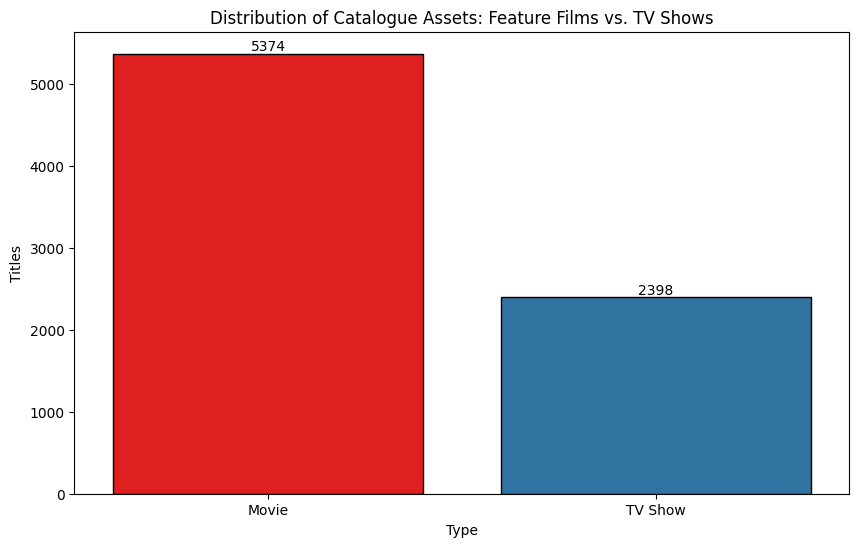

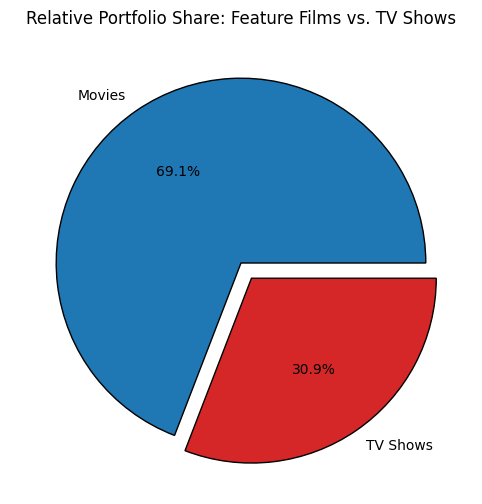

In [253]:
plt.figure(figsize=(10, 6)) # content type count plot
ax = sns.countplot(
    df_clean, x="Category",
    palette=['red', '#1f77b4'],
    order=['Movie', 'TV Show'],
    edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Distribution of Catalogue Assets: Feature Films vs. TV Shows")
plt.xlabel("Type")
plt.ylabel("Titles")
plt.show()

category_count = df_clean["Category"].value_counts()

plt.figure(figsize=(10, 6)) # content type pie chart
explode = (0, 0.1)
plt.pie(
    category_count,
    labels=['Movies', 'TV Shows'],
    colors=['#1f77b4', '#d62728'],
    autopct='%1.1f%%', explode=explode,
    wedgeprops={'edgecolor': 'black'})

plt.title("Relative Portfolio Share: Feature Films vs. TV Shows")
plt.show()

##### **Figure 1:** `Content Type Volume Comparison` 

**Distribution Disparity:** Movies represent the primary layer of the catalogue, totalling **5,374** unique films and securing a dominant **69.1%** share of the overall portfolio. Conversely, episodic content occupies a significantly smaller stake, generating **2,398** total entries to command the remaining **30.9%** of the catalogue.

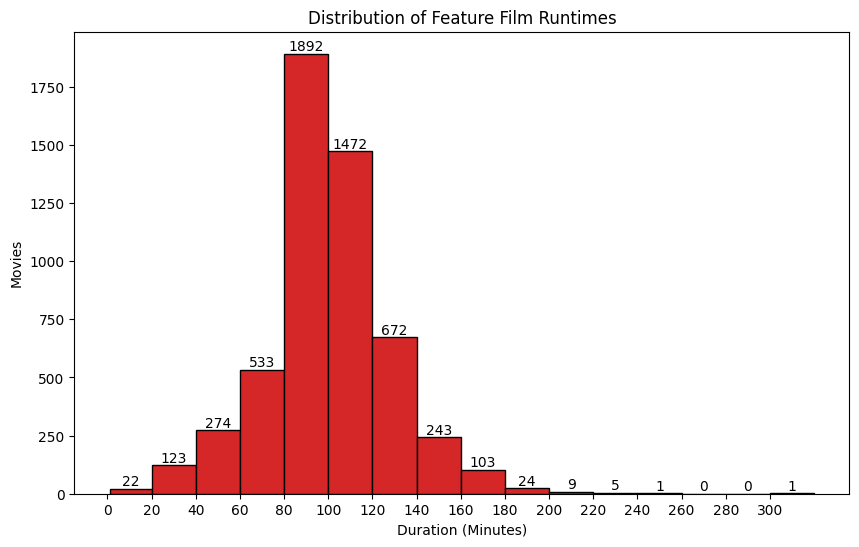

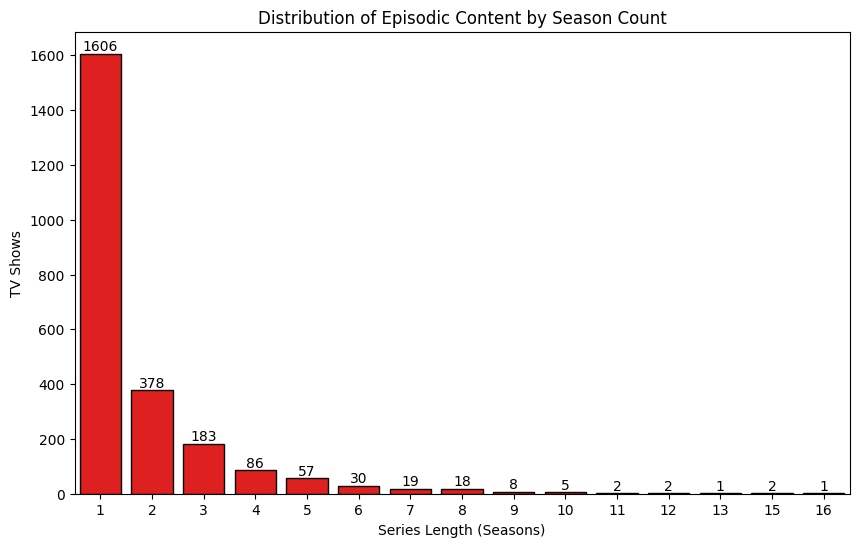

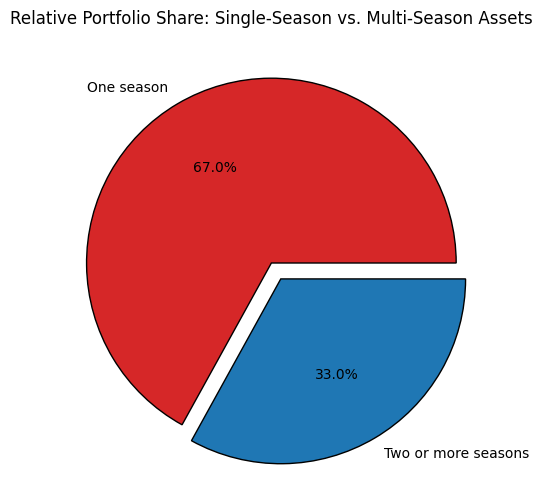

In [254]:
df_movies = df_clean[df_clean.Category == "Movie"]

plt.figure(figsize=(10, 6)) # movie runtime histogram
counts, bins, patches = plt.hist(
    x=df_movies.Duration,
    bins=[1, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320],
    color='#d62728',
    edgecolor='black')

plt.title("Distribution of Feature Film Runtimes")
plt.xlabel("Duration (Minutes)")
plt.xticks(np.arange(0, max(df_movies.Duration), 20))
plt.ylabel("Movies")
plt.bar_label(patches)
plt.show()

df_tvshows = df_clean[df_clean["Category"] != "Movie"]

plt.figure(figsize=(10,6)) # tv show season count plot
ax = sns.countplot(
    df_tvshows,
    x='Duration',
    color='red',
    edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Distribution of Episodic Content by Season Count")
plt.xlabel("Series Length (Seasons)")
plt.ylabel("TV Shows")
plt.show()

df_tvshows["Seasons"] = np.where(df_tvshows.Duration == 1, 1, 0)
season_count = df_tvshows["Seasons"].value_counts()

plt.figure(figsize=(10, 6)) # one vs. many season pie chart
plt.pie(
    season_count,
    labels=['One season', 'Two or more seasons'],
    colors=['#d62728', '#1f77b4'],
    autopct='%1.1f%%',
    explode=explode,
    wedgeprops={'edgecolor': 'black'})

plt.title("Relative Portfolio Share: Single-Season vs. Multi-Season Assets")
plt.show()

##### **Figure 2:** `Content Duration Distribution`

**General Trends & Observations:**

- **Movie Runtime:** Feature film lengths reveal a highly concentrated, normal dsitribution centering around the peaks within the **80-100** minute (**1,892** titles) and the **100-120** minute (**1,472** titles) windows. This runtime clustering proves that Netflix's film acquisition pipeline relies heavily on traditional cinematic runtimes. Outliers are generally infrequent, with runtimes under **40** minutes (short films/specials) and epics exceeding **160** minutes occupying a negligible share of the overall library.

- **Single-Season Dominance:** Single-season titles dominate the episodic format, accounting for approximately two thirds of all TV shows on the platform. This indicates a strategic push toward catalogue breadth and asset diversification, giving subscribers access to a wider range of content. By prioritising limited series and single season drops, Netflix quickly scales consumer choices, while testing customer sentiment regarding new global intellectual properties (IP) releases. This results in a steep decline from one season (**1,606** titles) shows to two season (**378** titles) shows.

**Catalogue Diversification:** This trend toward content diversification may correlate with the expansion of culturally and geographically diverse international markets, which will be analysed in **4.3 Geographical Insights**.

### **4.2 Catalogue Growth & Evolution**
### **Objective:** To identify the trajectory of the Netflix catalogue.

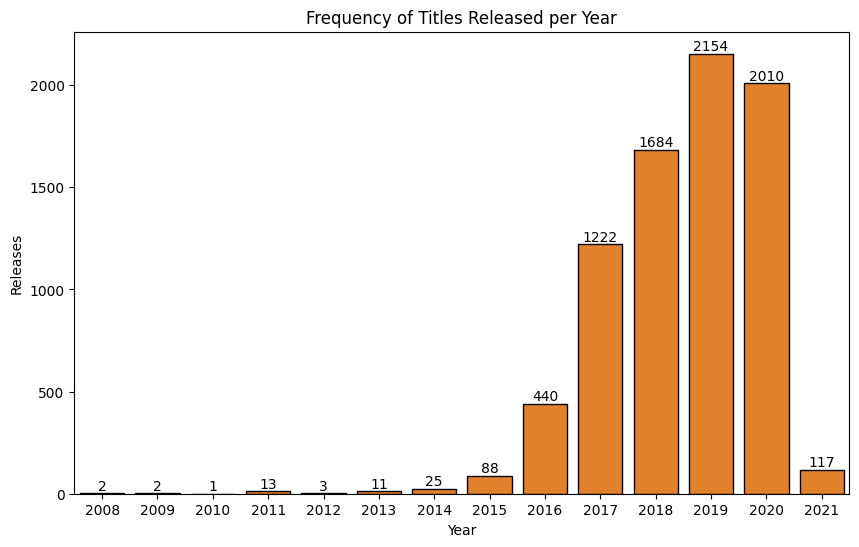

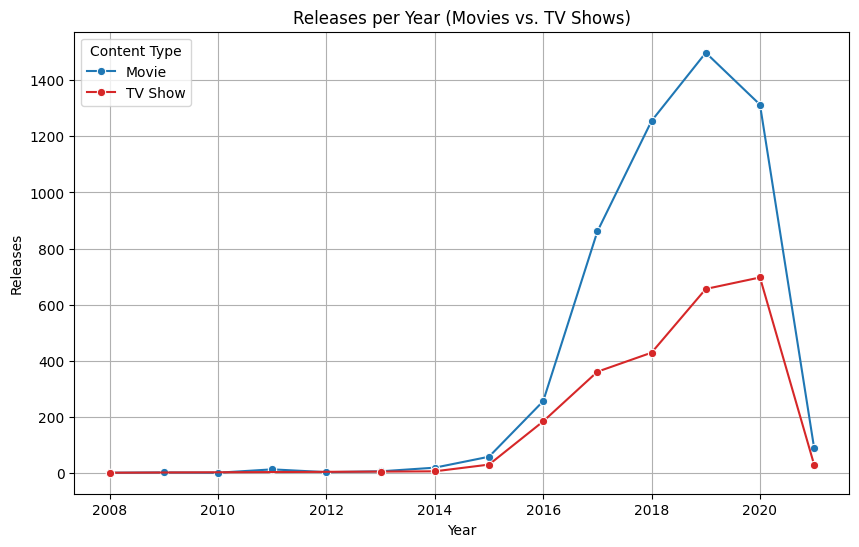

In [255]:
title_content = df_clean.sort_values("Release_Year")
title_content = title_content[title_content["Release_Year"] != 'Unknown']

plt.figure(figsize=(10, 6)) # frequency per title count plot
ax = sns.countplot(
    title_content, x="Release_Year",
    color='#ff7f0e', edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Frequency of Titles Released per Year")
plt.xlabel("Year")
plt.ylabel("Releases")
plt.show()

content_trends = (
    df_clean.groupby(["Release_Year", "Category"]).size()
    .reset_index(name="Count"))

content_trends = content_trends[content_trends["Release_Year"] != 'Unknown']

plt.figure(figsize=(10, 6)) # content type release line chart
sns.lineplot(
    content_trends,
    x="Release_Year", y="Count", hue="Category",
    marker='o', palette=['#1f77b4', '#d62728'])

plt.title("Releases per Year (Movies vs. TV Shows)")
plt.ylabel("Releases")
plt.xlabel("Year")
plt.legend(title="Content Type")
plt.grid()
plt.show()

##### **Figure 3:** `(A) Netflix Catalogue Growth and (B) Netflix Growth by Content Type`

**Release Frequency:** This dataset contains a significant expansion in the Netflix catalogue. The **2008-2014** period demonstrates a conservative, low-volume title output, averaging fewer than **30** releases annually. **Post-2015** marks a massive scaling phase that culminated in a peak of **2,154** additions in **2019**. While the sudden drop to **117** titles in **2021** appears severe, this contraction is likely due to incomplete data across **2021**, rather than an intentional halt.

**Movies vs. TV Shows Releases:** The **Figure 3B** highlights a fascinating operational shift during the global pandemic era. Historically, feature film output consistently outpaced episodic content. However, as the platform entered **2020**, movie releases experienced a sharp decline (plummeting from their **2019** peak of **~1,500** down to **~1,300**), while TV show additions continued to rise, hitting a lifetime peak of **700** releases. This shift aligns perfectly with the conditions induced by the global **COVID-19 lockdowns**, creating an unprecedented surge in home media consumption (Ofcom, 2020). Because episodic series demand higher viewing engagement and invested time, Netflix strategically prioritised TV show integration to monetise a captive, high-engagement audience during the peak lockdown cycle.

**Hypothesis 1:** Netflix is halting its content output velocity following the **2019** peak to mitigate the risks of platform oversaturation.

**Hypothesis 2:** Netflix is intentionally shifting its focus from standalone feature films to TV shows.

**Hypothesis Note:** The validity of **Hypothesis 2**, and further hypotheses stated requiring statistical testing in section **4. Exploratory Data Analysis (EDA)** will be explored in section **5. Statistical Testing**.

In [256]:
df_clean[df_clean.Release_Year == 2021].Release_Month.value_counts()

Release_Month
January    117
Name: count, dtype: int64

#### **Explanation**: Incomplete 2021 Data
The large drop in releases from **2020** to **2021** was indeed due to incomplete data beyond **January 2021**. This information will be relevant for my analysis under the following plot.

#### **Methodology:** Data Truncation Assessment
To investigate whether the **post-2020** volume collapse represents a data collection anomaly, this analysis isolates and cross-examines January release output. The evaluation is executed through two steps:
1. **Maximum Date Extraction:** Uncover the maximum date added within the **2021** subset to determine the exact boundary of the data collection window.

2. **Standardise Half-Month Release Volumes:** Calculate and compare aggregate release volumes for the first **16** days of **January 2016-2021** against the full month totals.

By benchmarking truncated intra-month output against historical patterns, this methodology mathematically demonstrates whether the **2021** downturn is empirical validation of a long-term production halt.

In [257]:
print("Most recent release in January 2021: Day", max(df_clean[(df.Release_Month == "January") & (df_clean.Release_Year == 2021)].Release_Day))

Most recent release in January 2021: Day 16


In [258]:
jan = df_clean[df_clean.Release_Month == "January"]
jan = (
    jan.groupby(["Release_Year"])["Release_Day"].count()
    .reset_index(name="January Releases"))
jan

,Release_Year,January Releases
0,2008,1
1,2014,2
2,2015,1
3,2016,44
4,2017,71
5,2018,130
6,2019,162
7,2020,228
8,2021,117


In [259]:
jan_16 = df_clean[(df_clean.Release_Month == "January") & (df_clean.Release_Day <= 16)]
jan_16 = (
    jan_16.groupby(["Release_Year"])["Release_Day"].count()
    .reset_index(name="Jan 1st-16th Releases"))
jan_16

,Release_Year,Jan 1st-16th Releases
0,2008,1
1,2016,38
2,2017,53
3,2018,93
4,2019,106
5,2020,173
6,2021,117


In [260]:
to_jan_16 = (
    df_clean[(df_clean.Release_Month == "January") & (df_clean.Release_Day <= 16) & (df_clean.Release_Year < 2021)]
    .shape[0])

post_jan_16 = (
    df_clean[(df_clean.Release_Month == "January") & (df_clean.Release_Day > 16)]
    .shape[0])

print(f"First half of January:   {to_jan_16} releases")
print(f"Second Half of January:  {post_jan_16} releases")
print(f"        Ratio:           {round(to_jan_16/post_jan_16, 2)}")

First half of January:   464 releases
Second Half of January:  175 releases
        Ratio:           2.65


#### **Justification:** Filtering for Trend Representativeness

To isolate the seasonal release patterns driving January output, the code below restricts the range of years to a specific window: from **1st January 2016** through **16th January 2021** (to the point of data truncation).

Prior to **2016**, the catalogue additions exhibit high data sparsity, with an exceptionally low volume of monthly releases. Including these early unpopulated years would introduce patterns unrepresentitive to the platform's modern, high-output catalogue-population strategies.

In [261]:
years = pd.DataFrame({"Release_Year": [i for i in range(2016, 2022)]})

# ensuring both DataFrames are from 2016 onwards
jan = jan[3:]
jan_16 = jan_16[1:]

jan = pd.merge(years, jan, on="Release_Year", how='left')
jan_16 = pd.merge(years, jan_16, on="Release_Year", how='left')

# DataFrame `jan` will now contain releases from the second half of January
jan["January Releases"] = jan["January Releases"] - jan_16["Jan 1st-16th Releases"]
jan_16.columns = jan_16.columns.str.replace("Jan 1st-16th Releases", "January Releases")

jan_16["Half"] = "First"
jan["Half"] = "Second"

jan_releases = pd.concat([jan_16, jan], axis=0)
jan_releases

,Release_Year,January Releases,Half
0,2016,38,First
1,2017,53,First
2,2018,93,First
3,2019,106,First
4,2020,173,First
5,2021,117,First
0,2016,6,Second
1,2017,18,Second
2,2018,37,Second
3,2019,56,Second


<Figure size 640x480 with 0 Axes>

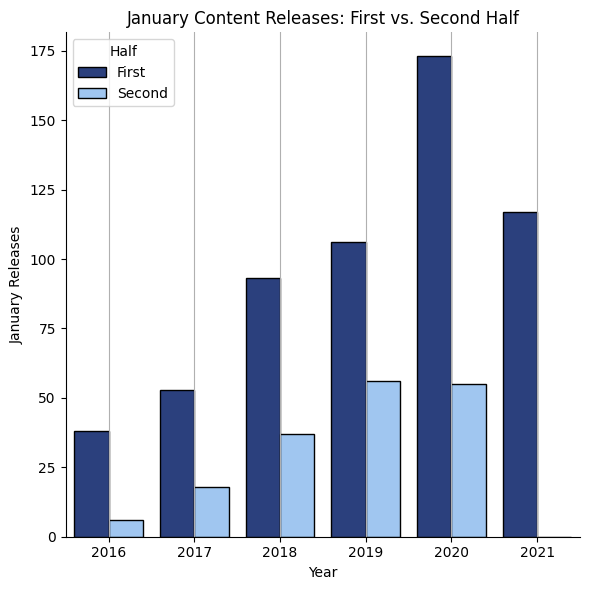

In [262]:
plt.figure()
sns.catplot(
    jan_releases,
    x="Release_Year", y="January Releases", hue="Half",
    kind='bar',
    palette=['#1E3A8A', '#93C5FD'],
    legend_out=False, edgecolor='black',
    height=6)

plt.title("January Content Releases: First vs. Second Half")
plt.xlabel("Year")
plt.tight_layout()
plt.legend(title="Half", loc='upper left')
plt.grid(axis='x')
plt.show()

##### **Figure 4:** `January Releases: New-Year Churn Anticipation`

**Front-Loaded Releases:** The data demonstrates a systematic skew toward the first half of January across all analysed years (excluding pre-**2016** and **2021**). The aggregated volume in the first sixteen days of each month significantly exceeds the latter half by a factor of **~2.65**. The front-loading of releases indicates a deliberate scheduling pattern rather than an organic distribution of content release.

**Platform Oversaturation & Churn Mitigation:** While the first half of January exhibits consistent year-on-year volume growth peaking in **2020**, total monthly output contracted between **2019** and **2020** due to a sharp proportional drop in second-half releases. This indicates Netflix's struggle against catalogue oversaturation, limiting releases following high-engagement windows. By compressing the majority of January's releases into the immediate opening days of the year, Netflix directly targets high subscriber engagement during a major winter holiday period, using massive content availability to reduce post-holiday subscriber churn.

**Hypothesis 3:** Netflix strategically increases content output around the New Year holiday as a retention tactic to mitigate subscriber churn.

#### **Hypothesis 1 Evaluation:** January 2020 Front-Loading

The volume surge in early January **2020** points to a reactive strategy designed to counteract the subscriber churn spikes observed in **2019**. By heavily front-loading the catalogue in early January **2020**, Netflix sought to anchor subscriber commitment at the beginning of the year. Over the longer term, the eventual moderation of these early-January content spikes from **2021** onwards suggests a transition away from raw volume-based retention. This shift directly correlates with the introduction of new payment plan introduced in November **2022**, an ad-supported subscription tier intended to capture price-sensitive consumers, which allowed the platform to mitigate churn via monetary accessibility rather than unsustainable content inflation.

In [263]:
df_clean.Release_Year.value_counts()

Release_Year
2019    2154
2020    2010
2018    1684
2017    1222
2016     440
2021     117
2015      88
2014      25
2011      13
2013      11
2012       3
2008       2
2009       2
2010       1
Name: count, dtype: Int64

In [264]:
print(f"Releases from years 2008 until the end of 2013 accounts for {round(100*df_clean[df_clean.Release_Year < 2014].shape[0]/df_clean.shape[0], 2)}% of all releases.")

Releases from years 2008 until the end of 2013 accounts for 0.41% of all releases.


#### **Justification:** January 2021 Removal

To ensure the integrity of seasonal analysis, the records for **January 2021** have been excluded from average calculation. Because the dataset terminates mid-month, the inclusion of this partial month would introduce a skewed reduction in output. 

In [265]:
months_order = ["January", "February", "March", "April",
                "May", "June", "July", "August", "September",
                "October", "November", "December"]

df_months = df_clean[(df_clean.Release_Month != "Unknown") & (df_clean.Release_Year != 2021)]
df_months.Release_Month = ( # ordering release months from January to December
    pd.Categorical(
        df_months.Release_Month,
        categories=months_order,
        ordered=True))

# restricting month names to first three letters for visualisation
df_months.Release_Month = df_months["Release_Month"].apply(lambda x: x[0:3])
df_months_clean = (
    df_months.groupby(["Release_Month", "Release_Year"])["Show_Id"].count()
    .reset_index(name="Count"))

monthly_releases = (
    df_months_clean.groupby(["Release_Month"])["Count"].mean()
    .reset_index(name="Average Releases"))
monthly_releases["Average Releases"] = round(monthly_releases["Average Releases"], 0)

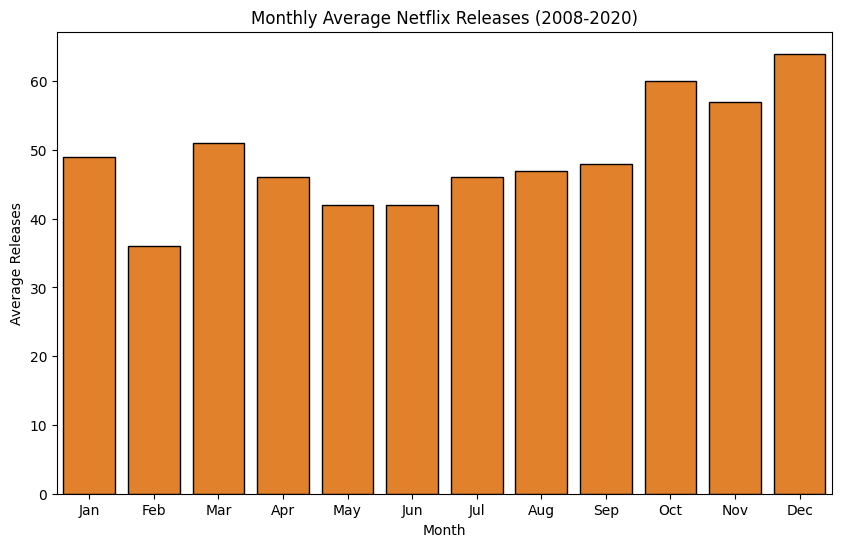

In [266]:
plt.figure(figsize=(10, 6))
sns.barplot(
    monthly_releases,
    x="Release_Month", y="Average Releases",
    color='#ff7f0e', edgecolor='black')

plt.title("Monthly Average Netflix Releases (2008-2020)")
plt.xlabel("Month")
plt.ylabel("Average Releases")
plt.show()

##### **Figure 5:** `Monthly Average Output` 

**General Trends:**
- **Seasonal Clustering:** A pronounced volume increase occurs throughout **October**, **November**, and **December** surrounding the major holidays of **Halloween** and **Christmas**. This acceleration represents a targeted audience engagement strategy. As falling seasonal temperatures incentivise indoor leisure activity, Netflix expands its catalogue to capture consumers' attention, leaning on high-volume, highly engaging content drops when subscriber demand peaks.

- **February Release Contrast:** Conversely, **February** exhibits the least volume output. Following four consecutive months of elevated releases, a scaled-back **February** prevents content oversaturation and manages expenditure. Additionally, this reduction accounts for the shorter month of **February** while offering subscribers an intentional consumption buffer to consume content from the prior high-release window before output accelerates again in **March**.

**Hypothesis 4:** Netflix increase the output of holiday-oriented content surrounding major holidays, leading to higher average monthly releases.

**Hypothesis 4 Note:** Although this sounds convincing, as Netflix can capitalise on customers' "
" through targeted seasonal releases, I must first check the genre releases during **October-December** to accept this claim.

**Hypothesis 3 Note:** I am unable to comment further that Netflix are increasing content increases around every New Year before checking the total releases on dates: **January 1st** and **December 31st**.

In [267]:
print("  --- Monthly Release Totals ---")
print(f"There were a total of {df_clean[(df_clean.Release_Month == "January") & (df_clean.Release_Year != 2021)].shape[0]} releases in January (excluding 2021).")
print(f"There were a total of {df_clean[df_clean.Release_Month == "December"].shape[0]} releases in December.")

print("\n  --- Jan 1st & Dec 31st Release Totals ---")
print(f"There were a total of {df_clean[(df_clean.Release_Month == "January") & (df_clean.Release_Day == 1)].shape[0]} releases on January 1st.")
print(f"There were a total of {df_clean[(df_clean.Release_Month == "December") & (df_clean.Release_Day == 31)].shape[0]} releases on December 31st.")

print("\n  --- Percentage of Releases per Month ---")
print(f"The number of releases on the 1st of January account for ~{round(320/6.39, 1)}% of total January releases (excluding 2021).")
print(f"The number of releases on the 31st of December account for ~{round(130/8.32, 1)}% of total December releases.")

  --- Monthly Release Totals ---
There were a total of 639 releases in January (excluding 2021).
There were a total of 832 releases in December.

  --- Jan 1st & Dec 31st Release Totals ---
There were a total of 320 releases on January 1st.
There were a total of 130 releases on December 31st.

  --- Percentage of Releases per Month ---
The number of releases on the 1st of January account for ~50.1% of total January releases (excluding 2021).
The number of releases on the 31st of December account for ~15.6% of total December releases.


#### **Hypothesis 3 Evaluation:** Holiday Scheduling & Active Churn Mitigation

The distribution of title additions above (from **2008** to **2021**) provides robust validation for **Hypothesis 3**, confirming a highly concentrated volume of releases surrounding the New Year:
- **January 1st Front-Loading:** The catalogue exhibits a major volume spike on **January 1st**, tracking an extraordinary **320** unique title additions. This single-day output accounts for just over a half (**~50.1%**) of the entire month's cumulative releases, representing a massive front-loading of catalogue assets.

- **New Year's Eve Closing Burst:** This strategy is mirrored on **December 31st**, which recorder **130** standalone releases. This year-end burst accounts for **~15.6%** of all December title additions.

This hyper-dense coordination of release dates confirms that Netflix deliberately uses the New Year holiday window to execute calculated, high-volume catalogue expansion. A definitive cross-evaluation of whether this scheduled output is a structured defence mechanism designed to suppress subscriber churn will be formally addressed in section **6. Key Insights & Conclusion**.

In [268]:
df_genre_clean.Genre.value_counts().head(25)

Genre
Dramas                       2810
International Movies         2437
Comedies                     1472
International TV Shows       1197
Documentaries                 786
Action & Adventure            721
Independent Movies            675
Children & Family Movies      532
Romantic Movies               531
TV Comedies                   517
Thrillers                     492
Crime TV Shows                426
Kids' TV                      411
Docuseries                    352
Romantic TV Shows             333
Stand-Up Comedy               329
Music & Musicals              321
Horror Movies                 312
British TV Shows              231
Reality TV                    222
Sci-Fi & Fantasy              218
Sports Movies                 196
Korean TV Shows               150
TV Action & Adventure         149
Spanish-Language TV Shows     146
Name: count, dtype: int64

#### **Seasonal vs. Non-Seasonally Targeted Genre Classes**

To isolate and verify the seasonal output driving **Hypothesis 4** (the targeted expansion of holiday-oriented content), a contrastive visualisation between two groups of genres. Rather than plotting an arbitrary subset of the catalogue, the data is separated into two distinct categories:
- **Targeted Seasonal Class (Expected Expansion):** Three distinct genres were selected based on their thematic alignment within the festive calendar window stretching from **October-December**. The genres **Children & Family Movies**, **Comedies**, and **Horror** function as an analytical lens to view the output in holiday-oriented intellectual property (IP).

- **Control Class (Expected Stagnation):** Two contrastive genres in **Documentaries** and **Sci-Fi & Fantasy**, conceptually decoupled from seasonally dictated release patterns, were mapped simultaneously to serve as an analytical control group.

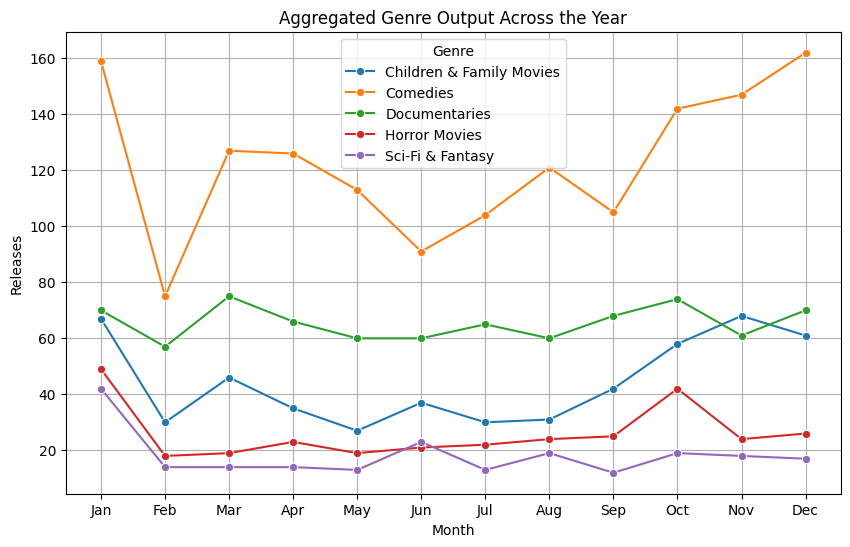

In [269]:
seasonal_genres = (
    df_genre_clean[(df_genre_clean.Genre == "Sci-Fi & Fantasy") | 
                   (df_genre_clean.Genre == "Documentaries") | 
                   (df_genre_clean.Genre == "Horror Movies") | 
                   (df_genre_clean.Genre == "Comedies") | 
                   (df_genre_clean.Genre == "Children & Family Movies")])

seasonal_genres = seasonal_genres[seasonal_genres.Release_Year != "2021"]
seasonal_genre_count = (
    seasonal_genres.groupby(["Release_Month", "Genre"])["Release_Year"].count()
    .reset_index(name="Count"))

seasonal_genre_count.Release_Month = pd.Categorical(
    seasonal_genre_count.Release_Month,
    categories=months_order,
    ordered=True)

seasonal_genre_count.sort_values("Release_Month")
seasonal_genre_count.Release_Month = seasonal_genre_count.Release_Month.apply(lambda x: x[:3])

plt.figure(figsize=(10, 6))
sns.lineplot(seasonal_genre_count, x="Release_Month", y="Count", hue="Genre", marker='o')
plt.title("Aggregated Genre Output Across the Year")
plt.xlabel("Month")
plt.ylabel("Releases")
plt.grid()
plt.show()

##### **Figure 6:** `Seasonal & Family Releases`

**Thematic Spikes:** The data validates the **September-December** seasonal clustering trend by exposing sharp volume increases in culturally targeted genres. **Comedies** and **Children & Family Movies** experience sustained output growth from **September-December**, aligning directly with peak family-centric holiday seasons. Concurrently, the **Horror** genre exhibits a localised, single-month spike in **October**. This stand-alone peak demonstrates a reactive strategy designed to capitalise on immediate, holiday-specific consumer demand.

**Release Consistency:** In contrast to seasonally volatile genres, **Documentaries** and **Sci-Fi & Fantasy** assume minimal variance across the standard calendar year. This stability supports **Hypothesis 4**, identifying these genres as "catalogue fillers" rather than tactical engagement drivers. The uniform spike across **all five** evaluated genres in **January** provides further empirical support for the platform-wide, front-loaded scheduling output outlined in **Figure 4**.

#### **Hypothesis 4 Evaluation:** Seasonal Holiday Releases

The empirical trends isolated in **Figure 6** provide sufficient validation to accept the hypothesis that Netflix systematically increases volume of targeted genres ahead of major calendar milestones.

In [270]:
mean_movie_duration = (
    df_movies.groupby(["Release_Year"])["Duration"].mean()
    .reset_index(name="Duration"))

season_length = (
    df_tvshows.groupby(["Release_Year"])["Duration"].mean()
    .reset_index(name="Seasons"))

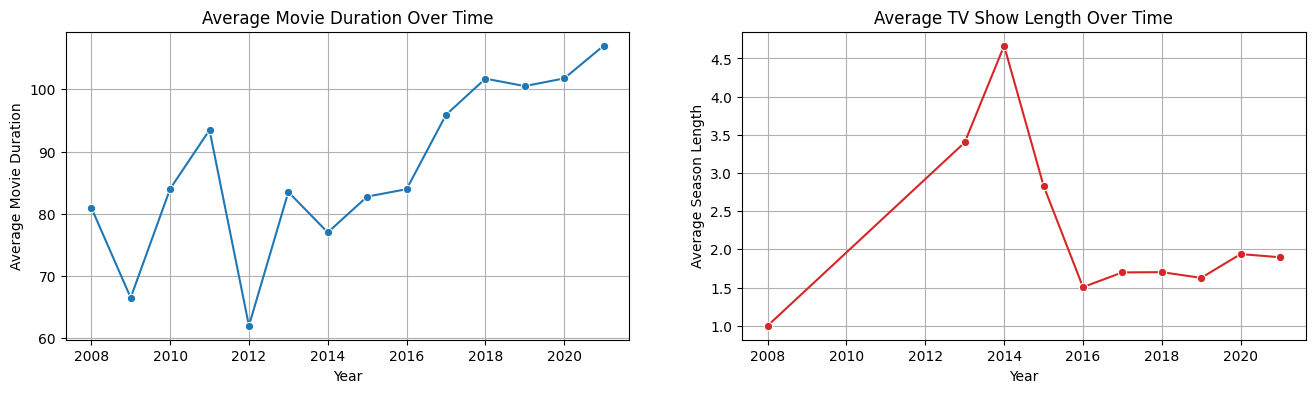

In [271]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plt.subplot(1, 2, 1) # average movie duration line plot
sns.lineplot(
    mean_movie_duration,
    x="Release_Year", y="Duration",
    marker='o',
    ax=axes[0])

axes[0].set_title("Average Movie Duration Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Movie Duration")
plt.grid()

plt.subplot(1, 2, 2) # average tv show length line plot
sns.lineplot(
    season_length,
    x="Release_Year", y="Seasons",
    marker='o',
    ax=axes[1],
    color='#d62728')

axes[1].set_title("Average TV Show Length Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Season Length")
plt.grid()
plt.show()

##### **Figure 7:** `Content Duration Evolution` 

**Movie Duration Trajectory:** The average runtimes for feature film additions display a steady upward trend from **2014** to **2021**. This volume expansion in longer-form assets directly reflects broader cinematic industry shifts over the past century, where top tier commercial and box-office releases have migrated toward or exceeded **120**-minute runtimes.

**TV Show Season Compression:** Following an absence of episodic releases between **2009** and **2012**, the average lifecycle of TV shows experienced a significant decline, falling from nearly five seasons down to an average of **1.5** to **2** seasons. This structural shift indicates an intentional content pivot from long-running series to unique and original content, hinting at Netflix's focus on highly varied content output.

**Ad Revenue:** The inflation of film runtimes pairs well with the introduction of the ad-supported subscription tier deployed in **November 2022** (Cain, 2022). This is due to mid-roll ad frequency directly scaling with duration, approximately **3.3** ads per hour for licensed titles and **3.78** ads per hour for original titles (Dougert, 2025), leading to increased ad-density per stream.

**Hypothesis 4:** The Netflix catalogue has become more globally diverse over time.

In [272]:
df_clean[df_clean.Release_Year < 2014].Release_Year.value_counts()

Release_Year
2011    13
2013    11
2012     3
2008     2
2009     2
2010     1
Name: count, dtype: Int64

In [273]:
print(f"{df_clean[df_clean.Release_Year <= 2013].shape[0]} releases before 2014")

32 releases before 2014


In [274]:
print(f"Corresponding to {round(100*df_clean[df_clean.Release_Year <= 2013].shape[0]/df_clean.shape[0], 2)}% of the releases across the 14 years accounted for in this dataset.")

Corresponding to 0.41% of the releases across the 14 years accounted for in this dataset.


#### **Justification:** Sporadic Runtime Averages 2008-2013

The extreme visual volatility observed in the historical trajectory of average movie runtimes between **2008** and **2013** is a consequence of an extremely restricted data pool. Across this six-year timeframe, the dataset records a cumulative total of only **32** film additions, averaging a negligible **5.3** releases per calendar year. This subset represents just **0.41%** of the total dataset. Rather than reflecting an intentional year-on-year shift in production formats, the sharp peaks and troughs are driven by data sparsity that disproportionality skews the annual average and creates an erratic trajectory. This smooths out only after **2014**, when Netflix's high-volume output began operating at scale.

### **4.3 Geographical Insights**
### **Objective:** To identify the leading countries in the Netflix catalogue.

**Disclaimer:** To accomodate this geographical analysis, the function below extracts a pandas `Index` structure of the top `n` countries. This index object is then passed directly into the `.isin()` method to filter the `df_country_clean` DataFrame to only the top `n` countries.

In [275]:
def top_country(n):
    return df_country_clean["Country"].value_counts().head(n).index

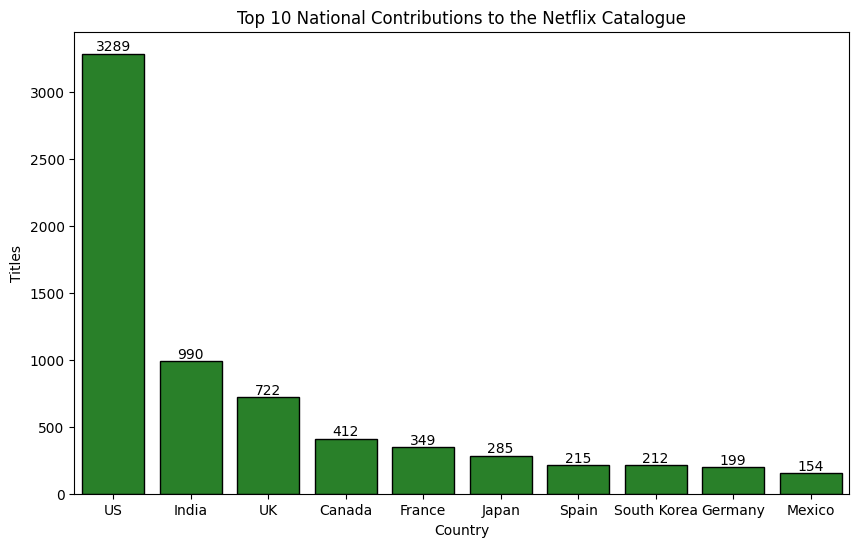

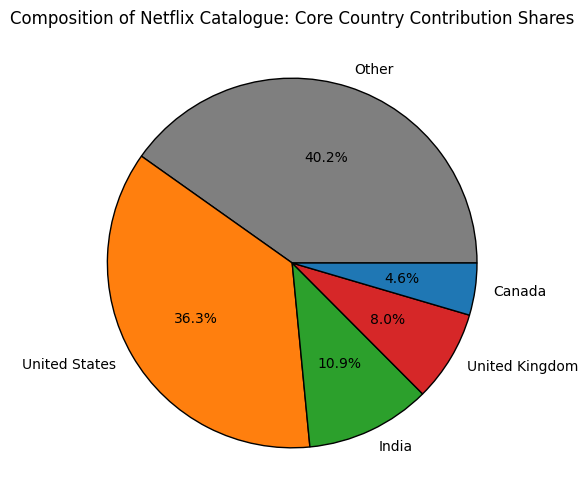

In [276]:
top_10_countries = top_country(10)
df_top_countries = df_country_clean[df_country_clean["Country"].isin(top_10_countries)]
df_top_countries.Country = df_top_countries.Country.str.replace("United Kingdom", "UK")
df_top_countries.Country = df_top_countries.Country.str.replace("United States", "US")

plt.figure(figsize=(10, 6)) # top 10 country count plot
ax = sns.countplot(
    df_top_countries, x="Country",
    order=df_top_countries.Country.value_counts().index,
    color='#1A8F1A', edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

ax.set_title("Top 10 National Contributions to the Netflix Catalogue")
ax.set_xlabel("Country")
ax.set_ylabel("Titles")
plt.show()

top_4_countries = top_country(4)
below_top_countries = df_country_clean[df_country_clean["Country"].isin(top_4_countries) == False]
below_top_countries.Country = "Other"
country_count = df_country_clean[df_country_clean["Country"].isin(top_4_countries)]
country_count = pd.concat([country_count, below_top_countries])

country_count = country_count["Country"].value_counts() # netflix catalogue country composition pie chart
plt.figure(figsize=(10, 6))
plt.pie(
    country_count,
    labels=country_count.index,
    colors=['#7f7f7f', '#ff7f0e', '#2ca02c', '#d62728', '#1f77b4'],
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'black'})

plt.title("Composition of Netflix Catalogue: Core Country Contribution Shares")
plt.show()

##### **Figure 8:** `Content Distribution by Country`

**Top 10 Regional Distribution by Volume:**  An evaluation of the top ten content-producing nations reveals an healthy geographic spread between key continents, comprising **four European**, **three Asian**, and **three American** territories. However, this superficial equality is heavily undermined by the sheer volume dominance of the United States. With **3,289** total additions, the **US** output nearly matches the cumulative volume of the remaining nine leading nations (**3,538** titles), and vastly eclipses its closest individual competitor, India (**990** titles).

**Netflix Catalogue Composition:** While the **United States** commands a massive **36.3%** of all releases, the drop-off across the rest of the world is incredibly sharp. This is best demonstrated by **Canada**, which despite securing the **4th** highest release count globally with **412** assets, accounts for a mere **4.6%** of the total catalogue share. This stark contrast with the US's expansive footprint provides insight into how little individual presence remaining countries occupy alone.

#### **Justification:** Global Heatmap
1. **Country Filtering:** The **US**, **UK**, and **India** were purposefully removed, as they have significantly more releases than any other country. Including these would result in the global heatmap displaying large areas across Europe and Asia as similar shades of purple which are hard to distinguish.

2. **Country Alignment:** To ensure compatibility between the cleaned dataset and the `geopandas` reference DataFrame (`world["NAME"]`), an index alignment audit was conducted. Non-matching entries were isolated through set difference:

In [277]:
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

set(df_country_clean["Country"]) - set(world["NAME"])

{'Bermuda',
 'Cayman Islands',
 'Czech Republic',
 'Dominican Republic',
 'East Germany',
 'Hong Kong',
 'Liechtenstein',
 'Malta',
 'Mauritius',
 'Samoa',
 'Singapore',
 'Soviet Union',
 'United States',
 'Vatican City',
 'West Germany'}

3. **Colourmap:** The `turbo` colourmap was selected to visualise output densities per country. Because the vast majority of nations occupy the lower bound of releases, the standard colourmap `viridis` lacked visual contrast required to distinguish subtle volume variations.

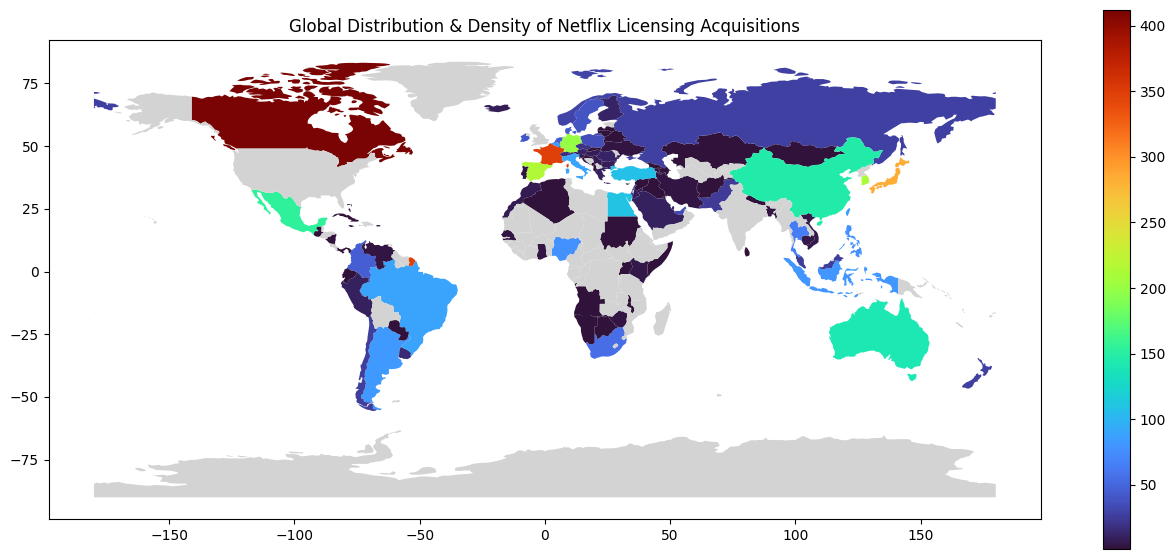

In [278]:
country_name_fix = {"East Germany": "Germany", "Czech Republic": "Czechia"}
df_country_clean["Country"] = df_country_clean["Country"].replace(country_name_fix)

valid_countries = set(world["NAME"])

df_country_clean_filtered = (
    df_country_clean[(df_country_clean["Country"].isin(valid_countries)) & 
                     (df_country_clean["Country"] != "United States of America") & 
                     (df_country_clean["Country"] != "India") & 
                     (df_country_clean["Country"] != "United Kingdom")])

country_counts = df_country_clean_filtered.groupby(["Country"]).size().reset_index(name="Count")

merged = world.merge(
    country_counts,
    left_on="NAME", right_on="Country",
    how='left')

fig, ax = plt.subplots(1, 1, figsize=(16, 7))
merged.plot(
    column="Count",
    ax=ax, legend=True,
    cmap='turbo',
    missing_kwds={'color': 'lightgrey'})

ax.set_title("Global Distribution & Density of Netflix Licensing Acquisitions")
plt.show()

##### **Figure 9:** `Visualisation of Global Content Distribution`

**Choropleth Map:** Content distribution is overwhelmingly skewed toward the **Northern Hemisphere**, matching global wealth concentration and established media infrastructure. Conversely, **Africa** remains almost entirely unrepresented within this dataset. **Northern** and **Eastern European** countries coupled with **Middle Eastern** countries (excluding Moldova, Bosnia, Kosovo, Macedonia, Yemen, and Oman) share very similar output concentrations, the only outlier with above **100** releases being **Turkey**.

In [279]:
top_7_countries = top_country(7)
df_top_5_countries_movies = (
    df_country_clean[(df_country_clean["Country"].isin(top_7_countries)) & 
                     (df_country_clean.Category == "Movie")])

df_top_5_countries_movies["Continent"] = (
    np.where(
        df_top_5_countries_movies.Country.isin(["India", "Japan"]) == True,
        "Asia", "Europe"))

df_top_5_countries_movies["Continent"] = (
    np.where(
        df_top_5_countries_movies.Country.isin(["United States", "Canada"]) == True,
        "North America", df_top_5_countries_movies["Continent"]))

df_top_5_countries_movies.head()

,Category,Country,Rating,Duration,Genre,Release_Day,Release_Month,Release_Year,Continent
3,Movie,United States,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...",16,November,2017,North America
4,Movie,United States,PG-13,123,Dramas,1,January,2020,North America
7,Movie,United States,R,119,Dramas,1,November,2019,North America
8,Movie,India,TV-14,118,"Horror Movies, International Movies",1,April,2019,Asia
9,Movie,India,TV-MA,143,"Horror Movies, International Movies, Thrillers",15,December,2017,Asia


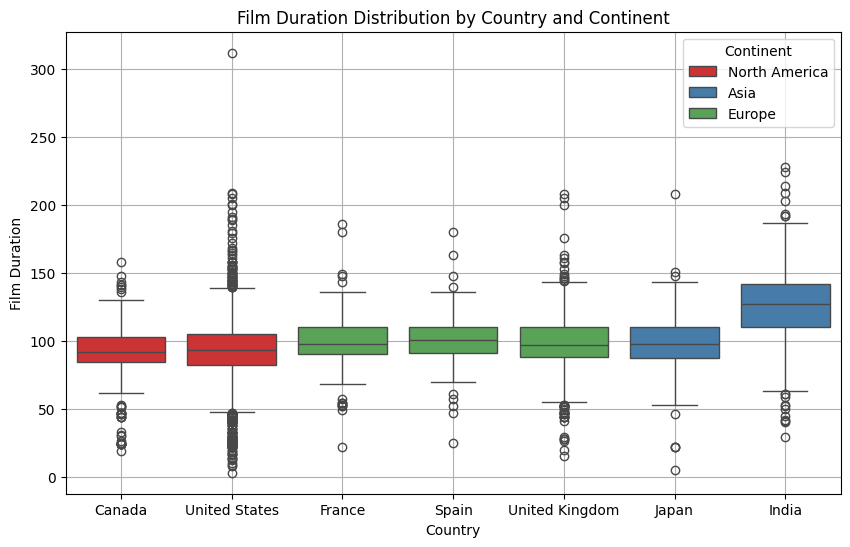

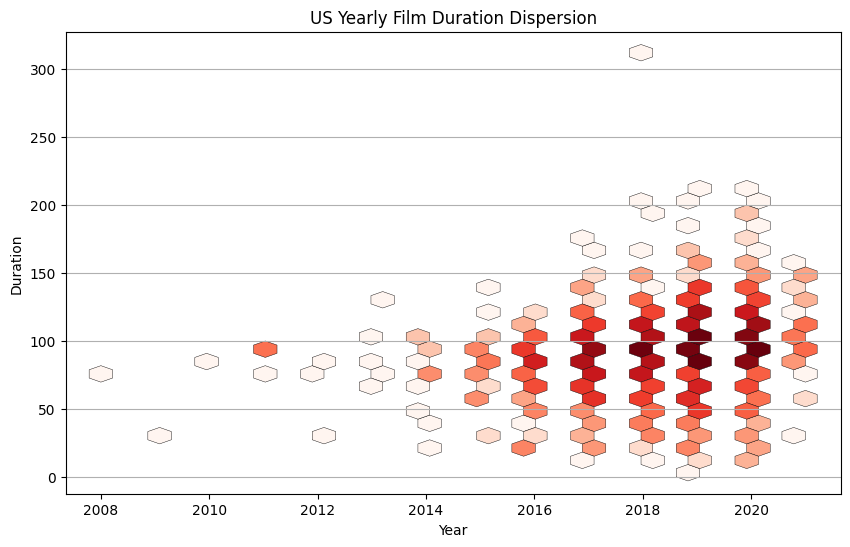

In [280]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    df_top_5_countries_movies,
    x="Country", y="Duration", hue="Continent",
    order=["Canada", "United States", "France", "Spain", "United Kingdom", "Japan", "India"],
    palette='Set1')

plt.title("Film Duration Distribution by Country and Continent")
plt.ylabel("Film Duration")
plt.grid()
plt.show()

df_us_durations = (
    df_top_5_countries_movies[df_top_5_countries_movies.Country == "United States"][["Release_Year", "Duration"]]
    .reset_index(drop=True))

plt.figure(figsize=(10, 6))
plt.hexbin(
    x=df_us_durations["Release_Year"], y=df_us_durations["Duration"],
    gridsize=30, mincnt=1,
    cmap='Reds', edgecolors='black',
    linewidths=0.3, bins='log')

plt.title("US Yearly Film Duration Dispersion")
plt.xlabel("Year")
plt.ylabel("Duration")
plt.grid(axis='y')
plt.show()

##### **Figure 10:** `(A) Cross-National Distribution of Film Duration & (B) Evolution of Content Duration Variance in the US Market`

**The Global Baseline Anomaly:** Analysis of Netflix's international catalogue (**Figure: 10A**) reveals a highly standardised global benchmark for cinematic runtimes. Across **European**, **East Asian**, and the majority of **North American markets**, quartile bounds and median durations are tightly between **75** and **115** minutes. However, the **Indian market** emerges as a stark **geographical anomaly**. While its lower whisker aligns with international norms, both quartiles and upper whisker are dramatically higher. The Indian median peaks at approximately **130** minutes, representing a significant departure from the **90** to **100** minute duration maintained by the other nations. This distinct distributional variance confirms a localised, market-specific production standard that heavily favours extended cinematic formats.

**United States Volatility:** Conversely, the United States exhibits an extreme distributional volatility. While maintaining a median in line with the global baseline (**~90-95** minutes), US cinematic runtimes are characterised by a dense concentration of outliers on both extremities of the runtime boxplot, including the maximum outlier in the dataset at over **300** minutes. To contextualise this dispersal strategy, a temporal scatterplot (**Figure 10B**) maps the US content duration spread over time. This temporal spread of runtimes reveals that the observed volatility is a relatively modern operational shift. Prior to **2015**, domestic runtimes were tightly clustered and the sudden variance hike correlates directly with the platform's rapid **2016** international scaling phase, demonstrating a deliberate abandonment of standard content formatting to nurture a diverse domestic portfolio.

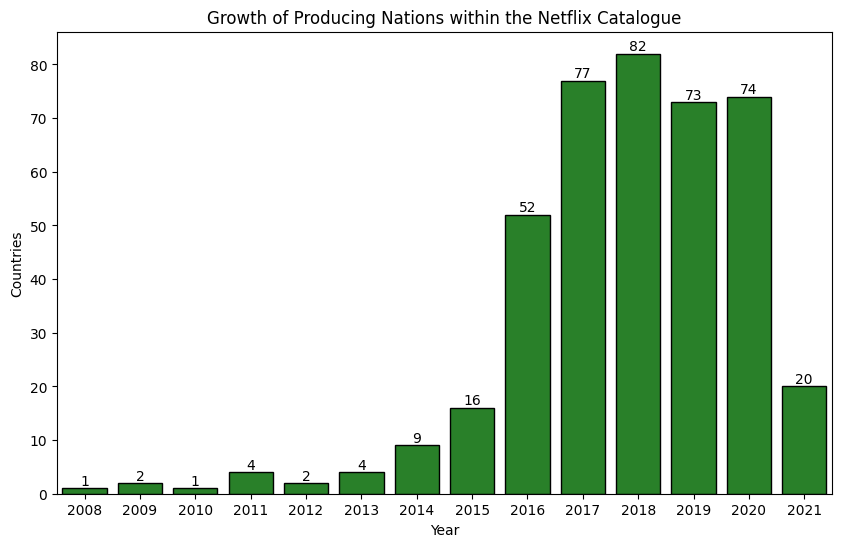

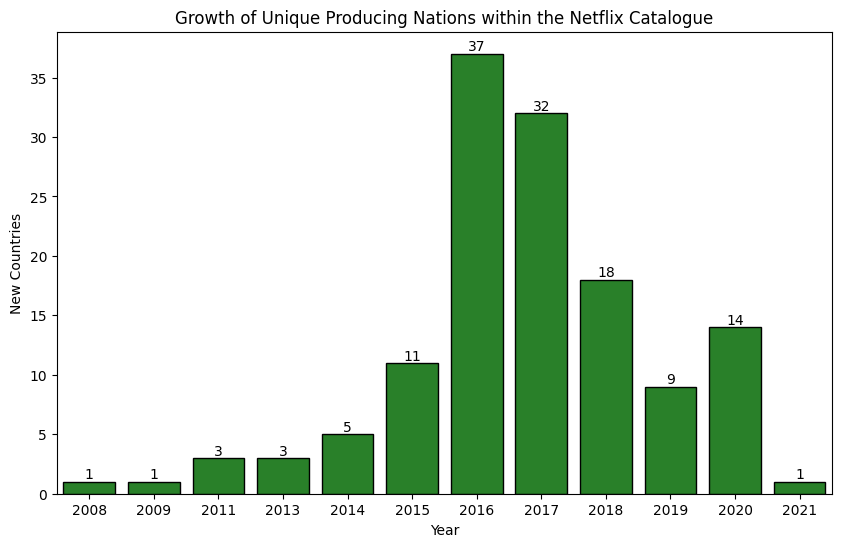

In [281]:
year_country = (
    df_country_clean.groupby(["Release_Year"])["Country"].nunique()
    .reset_index())

plt.figure(figsize=(10, 6)) # unique nations bar chart
ax = sns.barplot(
    year_country,
    x="Release_Year", y="Country",
    color='#1A8F1A', edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Growth of Producing Nations within the Netflix Catalogue")
plt.xlabel("Year")
plt.ylabel("Countries")
plt.show()

unique_countries = df_country_clean[df_country_clean.Release_Year == 2008]
for year in range(2008, 2021):
    countries_released = df_country_clean[df_country_clean.Release_Year == year].Country.unique()
    df_unique_countries = df_country_clean[df_country_clean.Country.isin(countries_released) != True]
    unique_countries = pd.concat([unique_countries, df_unique_countries[df_unique_countries.Release_Year == year + 1]])

unique_countries = (
    unique_countries.groupby(["Release_Year"])["Country"].nunique()
    .reset_index(name="Count"))

plt.figure(figsize=(10, 6)) # growth in unique countries bar chart
ax = sns.barplot(
    unique_countries,
    x="Release_Year", y="Count",
    color='#1A8F1A', edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Growth of Unique Producing Nations within the Netflix Catalogue")
plt.xlabel("Year")
plt.ylabel("New Countries")
plt.show()

##### **Figure 11:** `(A) Global Diversification & (B) Market Expansion`

**The 2016 Global Scaling:** The global diversity across **2008-2014** stands secluded from years **2016** onwards, with fewer than **10** total participating countries. A deliberate and aggressive international scaling phase occurred between **2015** and **2016**, where the total number of represented nations jumped from **16** to **52**. This sudden burst of diverse content reflects Netflix's global expansion event in **January 2016**, when the platform simultaneously launched services across **130** countries (Bitran, 2022), validating the drop in average season length found in **Figure 7**.

**Marginal Growth Decay & Market Saturation:** The sharp decline in unique country additions following the **2016-2017** peak (**32** and **37** new markets respectively) represents a market saturation curve. By the conclusion of **2017**, the platform's portfolio spanned **93** unique countries, approaching half of the globally recognised nations (**~195**). As the remaining markets narrows to territories lacking established digital infrastructure or media production hubs, the increase in global diversity naturally decelerated. Despite this, the platform maintained a steady marginal expansion through to **2020** before the **2021** temporal data truncation artificially suppressed the final calendar year releases.

#### **Hypothesis 4 Evaluation:** Geographic Diversification Across Timeline

The evidence gathered from **Figure 11** provides sufficient validation to accept the hypothesis that over the **2008-2021** period, content on Netflix has become more globally diverse.

In [282]:
print(f"Netflix contains releases from {unique_countries.Count.sum()} unique countries.")

Netflix contains releases from 135 unique countries.


This dataset has captured **135** unique countries, accounting for approximately **69.2%** of all nations in **13 years** of content release.

### **4.4 Genre Composition**
### **Objective:** To explore the relationship between genre and Netflix releases.

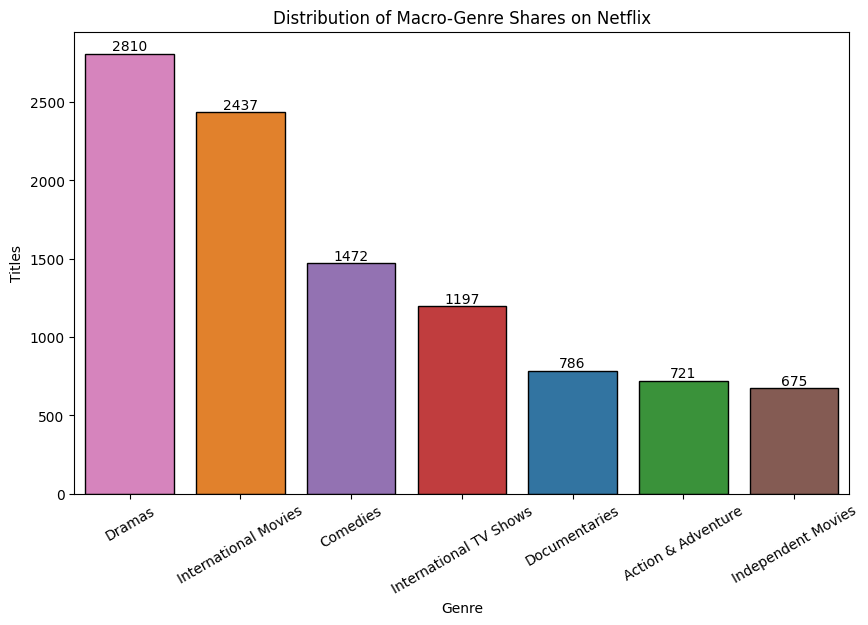

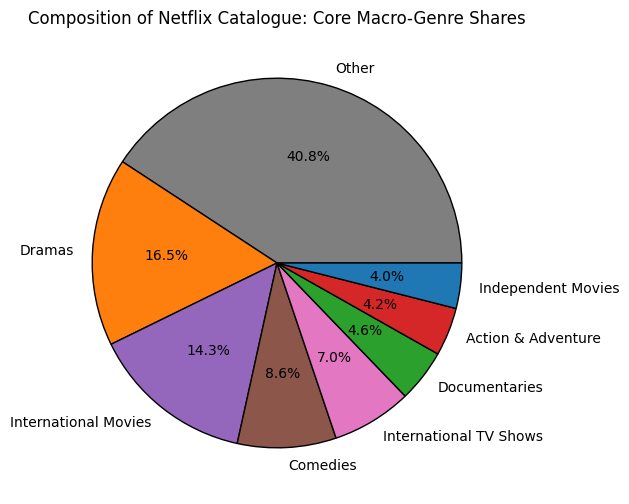

In [283]:
top_7_genres = df_genre_clean.Genre.value_counts().head(7).index
df_top_genre = df_genre_clean[df_genre_clean.Genre.isin(top_7_genres) == True]

plt.figure(figsize=(10, 6)) # distribution of top 7 genres count plot
ax = sns.countplot(
    df_top_genre, x="Genre",
    order=df_top_genre.Genre.value_counts().index,
    palette=['#e377c2', '#ff7f0e', '#9467bd', '#d62728', '#1f77b4', '#2ca02c', '#8c564b'],
    edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Distribution of Macro-Genre Shares on Netflix")
plt.xlabel("Genre")
plt.xticks(rotation=30)
plt.ylabel("Titles")
plt.show()

below_top_genres = df_genre_clean[df_genre_clean["Genre"].isin(top_7_genres) == False]
below_top_genres.Genre = "Other"
genre_count = pd.concat([df_top_genre, below_top_genres])

genre_count = genre_count["Genre"].value_counts() # top 7 genres vs. the rest pie chart
plt.figure(figsize=(10, 6))
plt.pie(
    genre_count, labels=genre_count.index,
    colors=['#7f7f7f', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#2ca02c', '#d62728', '#1f77b4'],
    autopct='%1.1f%%', wedgeprops={'edgecolor': 'black'})

plt.title("Composition of Netflix Catalogue: Core Macro-Genre Shares")
plt.show()

##### **Figure 12:** `Platform Share & Genre Dominance`

**Genre Aggregation:** Evaluating the catalogue's genre composition reveals that the top seven genres occupy approximately **59.2%** of total platform titles, leaving the remaining **40.8%** comprising secondary categories (**Other**). **Dramas** lead in catalogue listings representing **16.5%** of total additions. Combining international releases in **International Movies** (**14.3%**) and **International TV Shows** (**7.0%**) into a unified, international category represents **21.3%** of the total library, indicating that internationalisation remains pivotal to Netflix's distribution strategy.

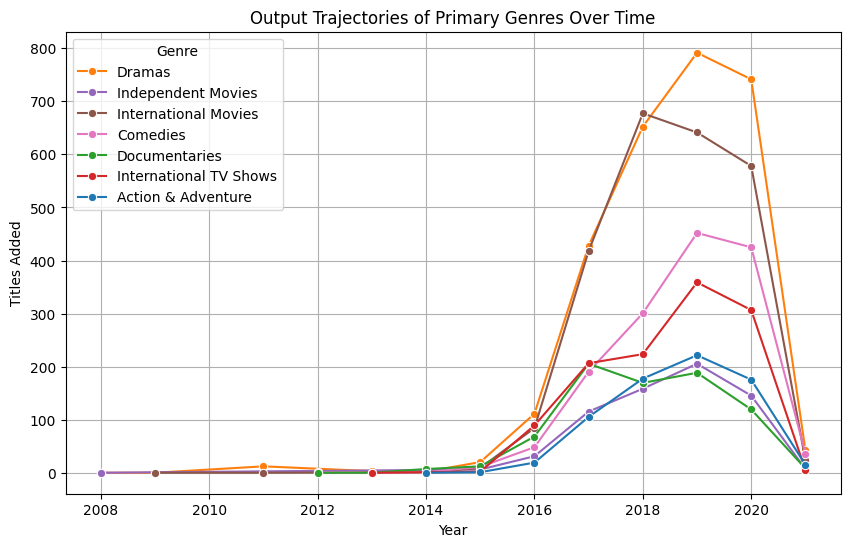

In [284]:
genre_trends = df_top_genre.groupby(["Release_Year", "Genre"]).size().reset_index(name="Count")

plt.figure(figsize=(10, 6))
sns.lineplot(
    genre_trends,
    x="Release_Year", y="Count", hue="Genre",
    marker='o',
    palette=['#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#2ca02c', '#d62728', '#1f77b4'])

plt.title("Output Trajectories of Primary Genres Over Time")
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.grid()
plt.show()

##### **Figure 13:** `Primary Genre Trajectory`

**Platform Scaling & Post-2019 Decline:** The timeline of genre output reveals a highly synchronised growth across the majority of best-performing categories, characterised by a sharp acceleration beginning in **2016** and a definitive peak in **2019**. The subsequent downward trajectory in **2020** and the severe collapse in **2021** are uniform across all genres, as confirmed by the truncated **2021** releases (**117** titles strictly within the first half of January) found below **Figure 3**. 

**Anomalous Trajectory of Documentaries:** While other primary genres continued their volume expansion until **2019**, documentary releases peaked prematurely in **2017** (**~200** titles) before experiencing a gradual decline. This divergence points to an early strategic reallocation of capital. Because documentary features carry lower production overheads but typically receive lower long-term subscriber retention and repeat-viewing "binge" metrics compared to **Dramas** or **Comedies**, Netflix throttled its documentary output early. This allowed the platform to pivot its capital expenditure toward high-engagement intellectual property (IP) ahead of intense **streaming competition** - the launches of Disney+ and Apple TV+ in **2019**, followed by HBO Max and Peacock in **2020-2021** prompted by the surge in **at-home viewing** caused by the **COVID-19 pandemic** (Berman, 2020) - emerging between **2018** and **2022**.

#### **Hypothesis 2 Evaluation:** Content Type Prioritisation

The contrasting release volume in international genre classes provide compelling validation for **Hypothesis 2**. **International Movies** reached a peak in **2018** (**~680** titles) before exhibiting a permanent reduction in output in the years to follow. The timeframe of this cinematic decline directly coincides with the steepest recorded growth for **International TV Shows**, which spiked significantly between **2018** and **2019**. This content type handoff demonstrates a deliberate diversion by Netflix to ease on international standalone feature film acquisition to prioritise international TV series, capitalising on the superior subscriber retention and long-term engagement metrics native to episodic content.

#### **Hypothesis 4 Evaluation:** Geographic Diversification Across Timeline

International content trends heavily reinforce **Hypothesis 4**, confirming that **internationalisation** is a **core strategy** rather than a temporary allocation phase. Both cross-border categories consolidated their positions within the top four for total releases of all time on the platform. This global focus is anchored by **International Movies** which briefly eclipsed **Dramas** in **2018** to become the **single largest content source** added to the library that year. The sheer volumetric dominance of these two categories across the timeline confirms a systematic, permanent diversification of the catalogue's geographic outreach.

### **4.5 Maturity Rating Trends**
### **Objective:** To determine Netflix's target audience.

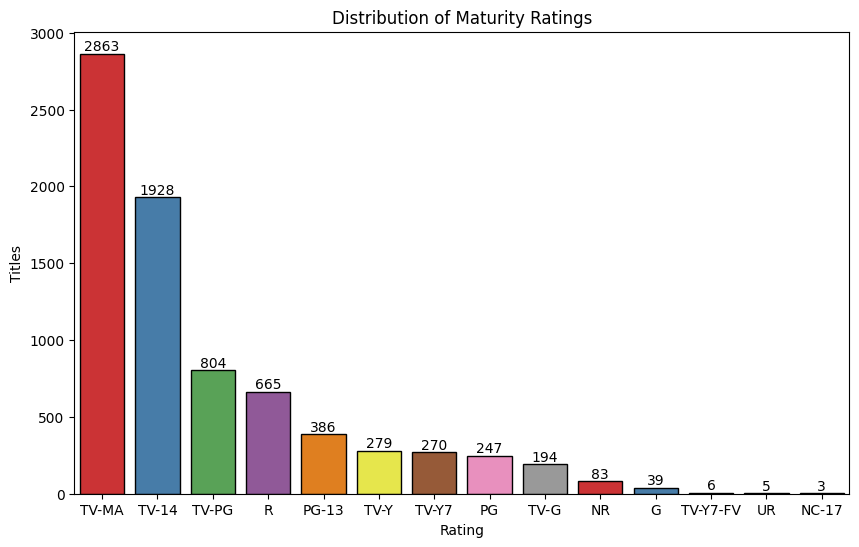

In [285]:
df_rating = df_clean[df_clean["Rating"] != "Unknown"]

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    df_rating,
    x="Rating",
    order=df_rating.Rating.value_counts().index,
    palette='Set1', edgecolor='black')

for value in ax.containers:
    ax.bar_label(value)

plt.title("Distribution of Maturity Ratings")
plt.xlabel("Rating")
plt.ylabel("Titles")
plt.show()

##### **Figure 14:** `Maturity Rating Distribution`

**Adult & Mature Audience Dominance:** Maturity rating distribution analysis reveals that mature content represents the primary foundation of Netflix's catalogue. The **TV-MA** (Mature Audience) classification functions as the single largest volume category with **2,861** titles, outpacing the second-highest tier, **TV-14** (Parents Strongly Advised), by a margin of nearly **1,000** releases. When aggregated, the top five classifications are overwhelmingly comprised of tiers requiring parental intervention or strict age thresholds (**TV-MA**, **TV-14**, **TV-PG**, **R**, **PG-13**).

**Marginal Share of Youth Programming:** Conversely, content releases strictly for a younger demographic occupy a highly restricted share of the overarching portfolio. Early childhood and juvenile classifications, such as **TV-Y** (All Children) and **TV-Y7** (Directed to Older Children), generate minimal standalone volume, tracking **279** and **270** titles respectively. This asymmetry in release volume indicates that Netflix's catalogue optimisation model is heavily skewed toward teenage and adult subscriber bases, positioning the platform as a mature entertainment service rather than a child-centric media provider.

**Disclaimer:** Below, **TV-MA** appears in the `family_ratings` list, however is removed in **Figure 15B**. This is due to further necessary statistical testing for **Hypothesis 5**, stated under **Figure 15**.

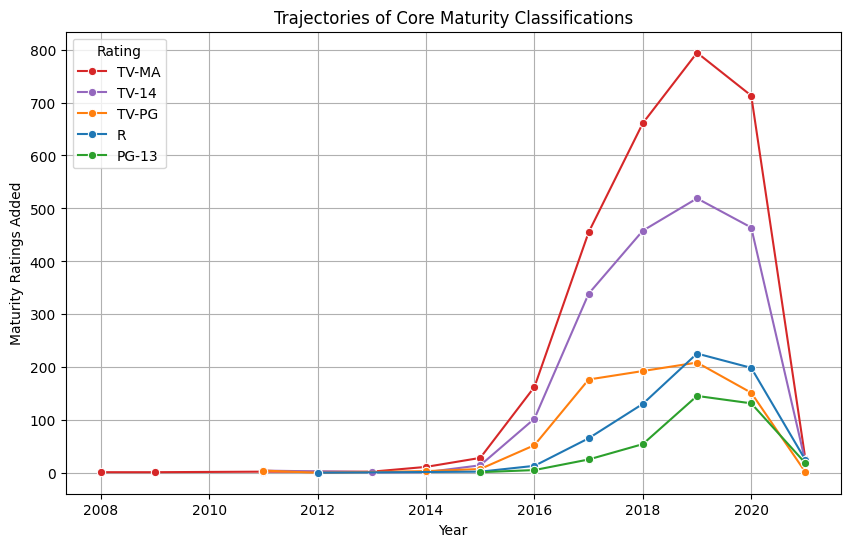

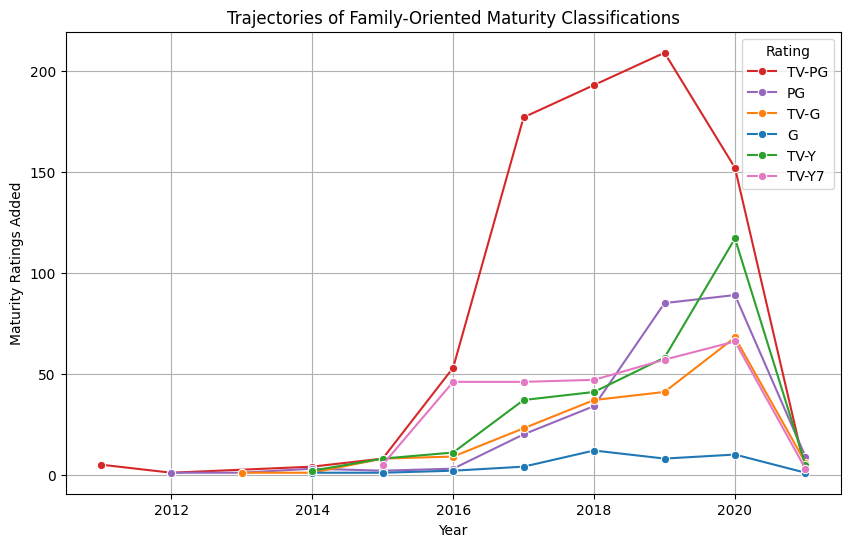

In [286]:
top_5_ratings = df_rating.Rating.value_counts().head().index
df_top_ratings = df_rating[df_rating.Rating.isin(top_5_ratings)]
rating_trends = (
    df_top_ratings.groupby(["Release_Year", "Rating"]).size()
    .reset_index(name="Count"))

plt.figure(figsize=(10, 6)) # top rating line chart
sns.lineplot(
    rating_trends,
    x="Release_Year", y="Count", hue="Rating",
    marker='o',
    palette=['#d62728', '#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c'])

plt.title("Trajectories of Core Maturity Classifications")
plt.xlabel("Year")
plt.ylabel("Maturity Ratings Added")
plt.grid()
plt.show()

family_ratings = ["G", "PG", "TV-Y", "TV-Y7", "TV-G", "TV-PG", "TV-MA"]
df_family_ratings = df_rating[df_rating.Rating.isin(family_ratings)]

family_ratings_trends = (
    df_family_ratings.groupby(["Release_Year", "Rating"]).size()
    .reset_index(name="Count"))

plt.figure(figsize=(10, 6)) # family-oriented rating line chart
sns.lineplot(
    family_ratings_trends[family_ratings_trends.Rating != "TV-MA"],
    x="Release_Year", y="Count", hue="Rating",
    marker='o',
    palette=['#d62728', '#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c', '#e377c2'])

plt.title("Trajectories of Family-Oriented Maturity Classifications")
plt.xlabel("Year")
plt.ylabel("Maturity Ratings Added")
plt.grid()
plt.show()

##### **Figure 15:** `(A) Trajectory of Maturity Ratings & (B) Family-Oriented Maturity Ratings`

**TV-PG Stagnation:** The chronological distribution of content ratings reveals a distinct favour for family-accessible content. The **TV-PG** rating saw an expansion phase between **2016** and **2017**, where additions more than tripled. However, this growth immediately flattened into a multi-year plateau from **2017** through **2019**, fluctuating tightly around the **~180** to **~200** annual title threshold. This early stagnation indicates that Netflix reached its desired baseline volume for parental guidance content early in its scaling phase.

**Mature Content Cross-Over:** Crucially, during this exact **TV-PG** stagnation window, mature content saw unrestricted growth. The strictly adult **R** rating maintained a steep gradient from **2016** onwards, culminating in a critical intersection point in **2019** where it overtook **TV-PG** in releases.

**The 2020 Pivot & Early Childhood Acceleration:** While **TV-PG** additions experienced a decline in **2020** (dropping from **over 200** releases to **~150**), younger demographic classifications saw a significant expansion in releases. Specifically, **TV-Y** (content for children aged 2-6) experienced a surge in output, climbing to a peak of **~120** additions in **2020**. This indicates a targeted reallocation of production assets toward early-childhood animations during a period of massive global home-confinement, benefiting from captive daytime household viewership.

**Hypothesis 5:** Netflix is trying to cultivate a more family-oriented viewer base.

#### **Justification:** Rating Index Alignment

Initially, I created a DataFrame that isolated the top four maturity ratings unique to the top four nations. However, because the primary classification tiers varied across these countries, the resulting grouped bar chart would be asymmetrical with gaps (empty spaces where a specific rating accounted for zero title contribution for a country).

To alleviate this visual fragmentation and ensure total metric comparability, the four most abundant ratings: **R**, **TV-14**, **TV-MA**, and **TV-PG** were selected to standardise ratings across all four production hubs. This ensures a symmetrical chart layout, enabling a direct comparison of regional distribution profiles.

In [287]:
top_4_countries = df_country_clean["Country"].value_counts().head(4).index
country_ratings = df_country_clean[df_country_clean["Country"].isin(top_4_countries)]
country_ratings = (
    country_ratings.groupby(["Country", "Rating"]).size()
    .reset_index(name="Count"))

top_4_ratings = df_clean["Rating"].value_counts().head(4).index
country_ratings = country_ratings[country_ratings["Rating"].isin(top_4_ratings)]

country_ratings

,Country,Rating,Count
5,Canada,R,68
6,Canada,TV-14,47
8,Canada,TV-MA,100
9,Canada,TV-PG,39
17,India,R,5
18,India,TV-14,542
20,India,TV-MA,246
21,India,TV-PG,142
30,United Kingdom,R,120
31,United Kingdom,TV-14,97


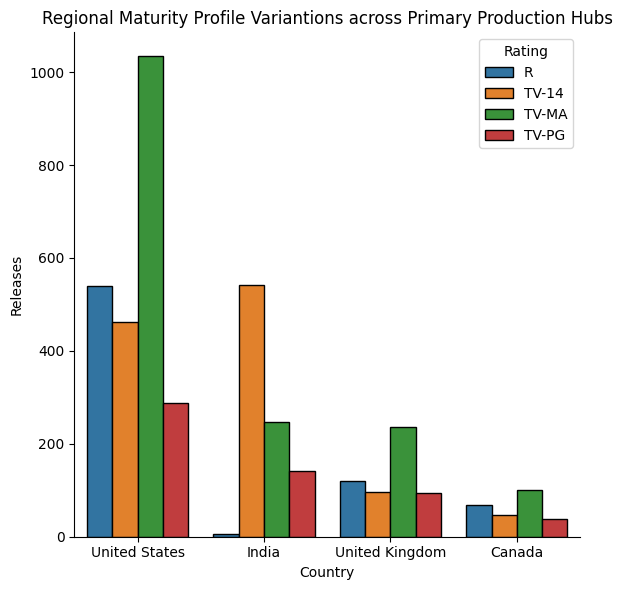

In [288]:
sns.catplot(
    country_ratings,
    x='Country', y="Count", hue="Rating",
    kind='bar',
    order=df_country_clean["Country"].value_counts().head(4).index,
    legend_out=False,
    edgecolor='black', height=6)

plt.title("Regional Maturity Profile Variantions across Primary Production Hubs")
plt.ylabel("Releases")
plt.tight_layout()
plt.legend(title="Rating", loc='upper right')
plt.show()

##### **Figure 16:** `Maturity Rating Profiles Across Primary Production Hubs`

**Cultural Inversion:** The **United States** exhibits a massive portfolio geared toward mature demographics, with **TV-MA** (**1,033** titles) and **R** (**539** titles) functioning as its dominant distribution pillars. Conversely, **India's** catalogue features a structural inversion: **TV-14** serves as the leading category with **542** titles, while strictly adult **R**-rated content sits at a measly **5** titles.

**Portfolio Alignment:** The **United Kingdom** and **Canada** display highly proportionate distribution patterns with **TV-MA** maintaining a clear lead, closely followed by **R** and consistent parental guidance categories (**TV-14** and **TV-PG**). This consistency indicates that Netflix operates on a uniform content output basis across Western markets, contrasting sharply with the highly conservative, television-centric layout required to capture and retain the South Asian subscriber market.

**Indian Censorship Laws:** The near-total absence of mature Indian content within this dataset is a result of the strict media guidelines governed by the **Central Board of Film Cerfitication (CBFC)**. Under the Cinematograph Act of **1952**, any commercial feature film intended for public exhibition in India must receive certification from this board (Wikipedia, 2026).

#### **Justification:** International Content Aggregation

To evaluate the distribution of maturity ratings across core thematic categories, the cross-border classes (**International Movies** and **International TV Shows**) were consolidated into a single category: **International Content**.

Prior to this aggregation, an exploratory data audit confirmed that both film and episodic international additions exhibit an almost identical distribution profile, characterised by a heavy concentration of **TV-MA** and **TV-14** ratings. Treating them separately would have introduced visual redundancy. By collapsing these into a single category based on their shared distribution profile, a categorical slot was freed up, enabling the inclusion and visualisation of an additional distinct genre, **Documentaries**, providing a richer comparative basis for the following grouped bar chart.

In [289]:
top_5_genres = df_genre_clean["Genre"].value_counts().head(5).index
genre_ratings = df_genre_clean[df_genre_clean["Genre"].isin(top_5_genres)]

genre_ratings.Genre = genre_ratings.Genre.replace("International Movies", "International Content")
genre_ratings.Genre = genre_ratings.Genre.replace("International TV Shows", "International Content")

genre_ratings = (
    genre_ratings.groupby(["Genre", "Rating"]).size()
    .reset_index(name="Count"))

genre_ratings = genre_ratings[genre_ratings["Rating"].isin(top_4_ratings)]
genre_ratings

,Genre,Rating,Count
5,Comedies,R,153
6,Comedies,TV-14,424
8,Comedies,TV-MA,375
9,Comedies,TV-PG,146
18,Documentaries,R,23
19,Documentaries,TV-14,203
21,Documentaries,TV-MA,287
22,Documentaries,TV-PG,159
28,Dramas,R,328
29,Dramas,TV-14,860


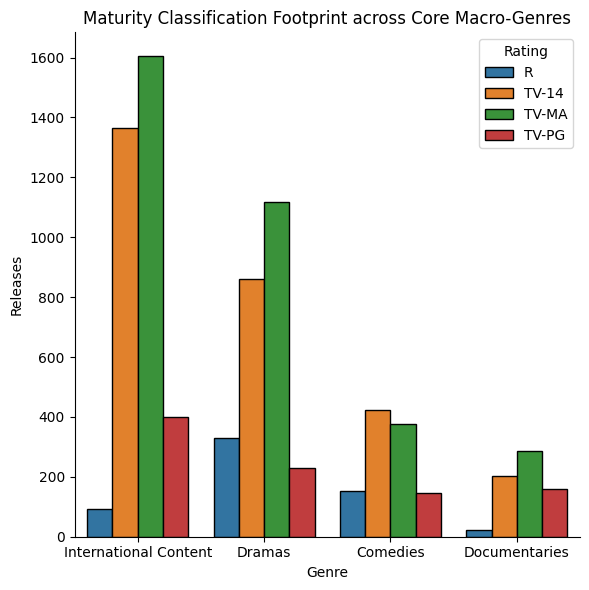

In [290]:
sns.catplot(
    genre_ratings,
    x="Genre", y="Count", hue="Rating",
    kind='bar',
    order=["International Content", "Dramas", "Comedies", "Documentaries"],
    legend_out=False,
    edgecolor='black', height=6)

plt.title("Maturity Classification Footprint across Core Macro-Genres")
plt.ylabel("Releases")
plt.tight_layout()
plt.legend(title="Rating", loc='upper right')
plt.show()

##### **Figure 17:** `Maturity Rating across Macro Genre Categories`

**International Maturity Benchmark:** For international assets, **TV-MA** stands as the absolute leading classification with **1,604** titles, closely paired with **TV-14** releases (**1,366** titles). This high concentration confirms that Netflix's cross-border licensing pipeline prioritises complex, adult-oriented narrative properties tailored for mature demographic cohorts rather than a universal, all-ages focus.

**Genre-Specific Dynamics:**
- **Dramas:** Mirroring the international sector, **Dramas** are heavily anchored by **TV-MA** (**1,116** titles) and **TV-14** (**860** titles), while family-accessible **TV-PG** entries remain a low-priority minority class.

- **Comedies:** This is the only macro genre where the parental cautionary **TV-14** (**424** titles) maturity rating physically eclipses **TV-MA** (**374** titles), illustrating a strategic shift toward a broader accessibility within humour-centric releases.

- **Documentaries:** Despite a smaller absolute scale due to the premature **2017** volume cap identified in **Figure 13**, titles with **TV-MA** and **TV-14** maturity ratings remain balanced, with low-overhead **R**-rated features remain sparse.

---
<a id="stat"></a>
## **5. Statistical Testing**

### **5.1 Hypothesis 2:** Netflix's Strategic Catalogue Shift

#### **5.1.1 Statistical Methodology Overview**

During Exploratory Data Analysis, **Figure 2** exposed a critical structural shift within Netflix's catalogue: standalone feature film releases peaked in **2019**, dominating in volume over TV shows, before exhibiting a release contraction in **2020**. Concurrently, **2020** marked a historic event where TV show additions surpassed film releases for the first time in the platform's history. This two-year release inversion isolates the exact boundary where this strategic pivot is hypothesised to have originated. Furthermore, because this dataset experiences extreme truncation **post-2020**, the release years required are intentionally restricted to the **2019-2020** window to preserve model validity.

To investigate whether Netflix is executing an intentional long-term strategic pivot from standalone feature films to TV series, a contingency table with categorical variables `Release_Year` and `Category` was constructed around the pivotal **2019-2020** transition window. Rigorously evaluating this contingency table involves an inference pipeline that uses the two-step process: a **Pearson's Chi-Squared $(\chi^2)$ Test of Independence** to confirm the presence of a non-random shift, followed immediately by a **Cramer's $V$ Coefficient** to quantify the real-world scale of that change.

##### **Pearson's Chi-Square $(\chi^2)$ Test of Independence**

The Chi-Square statistic is an inferential, non-parametric test designed to uncover whether a statistically significant relationship exists between two categorical variables. Unlike many other non-parametric and some parametric statistics, the calculations needed to compute the Chi-Square provide considerable information regarding performance of each group in the study. This abundance of detail allows for reliable interpretability of results and thus to derive more comprehensive information than many other statistics (McHugh, 2023). We can calculate the $\chi^2$ test statistic (total deviation) using the following formula:

$$\chi^2 = \sum_{ij}{\frac{(O_{ij} - E_{ij})^2}{E_{ij}}}$$
where:
1. $O_{ij} = $ Observed frequency in row $i$ and column $j$,
2. $E_{ij} = $ Expected frequency in row $i$ and column $j$, (BMC Med Res Methodol, 2025)

##### **Cramer's $V$ Coefficient (Effect Size)**

While a Chi-Square test can verify that a shift has taken place, it suffers from the limitation that its output scales directly with the volume of data $(N)$ (Bergh, 2015). Large datasets can produce significant *$p$-values* for trivial differences, while small samples may miss real-world associations.

To correct for this sensitivity, a Cramer's $V$ coefficient is calculated. It standardises the Chi-Square output into a fixed descriptive scale between 0 (complete independence) and 1 (perfect correlation). For a $2 \times 2$ table, Cramer's $V$ is mathematically identical to Cohen's $w$ (this is the effect size that is mostly resistant to sample size influence, providing a truer measure of the magnitude of effect between variables (Ferguson, 2009)) and is capable of isolating the actual strength of the strategic shift. The following formula is used:

$$V = \sqrt{\frac{\chi^2 / N}{\min(i-1, \space j-1)}} = \sqrt{\frac{\chi^2}{N}} = w, \space \space \space \space i = j = 2$$

where:
1. $\chi^2 = $ Chi-Square statistic,
2. $N = $ Total sample size, (BMC Med Res Methodol, 2025)
3. $i, \space j$ are the number of rows and columns, respectively.

By introducing Cramer's $V$ (Cohen's $w$), this ensures the verification of Netflix's catalogue adjustment, revealing whether the platform is executing a structural overhaul.

#### **5.1.2 Hypothesis Formulation**

The test is defined as follows:
- **$H_0$ (Null Hypothesis):** The distribution of catalogue additions by content type (Movies vs. TV Shows) is independent of the release year (**2019** vs. **2020**).
- **$H_1$ (Alternative Hypothesis):** The distribution of catalogue additions by content type is dependent on the release year.

A significance level $(\alpha)$ of $1 \% \space (\alpha = 0.01)$ was deliberately chosen for this instead of the traditional choice of $5 \%$. Lowering the significance level makes the test stricter, requiring stronger evidence to reject the null hypothesis and ensuring that any flagged directional shift is more robust.

#### **5.1.3 Statistical Application**

##### 1. **Contingency Table Formulation**

In [291]:
df_2019_2020 = df_clean[df_clean.Release_Year.isin([2019, 2020])]
contingency_table = pd.crosstab(df_2019_2020.Category, df_2019_2020.Release_Year)
contingency_table

Release_Year,2019,2020
Category,,
Movie,1498,1313
TV Show,656,697


##### 2. **$\chi^2$ Test Statistic, *$p$-value* & Cramer's $V$**

In [292]:
def chiSquare_cramerV(table):
    X2, p_value, dof, _ = chi2_contingency(table)
    print(f"Chi-Square test statistic: {round(X2, 2)}, with {dof} degree of freedom and p-value: {round(p_value, 5)}")

    N = table.sum().sum()
    cramers_V = np.sqrt(X2/N)
    print(f"\nCramer's V: {round(cramers_V, 4)}")

In [293]:
chiSquare_cramerV(contingency_table)

Chi-Square test statistic: 8.26, with 1 degree of freedom and p-value: 0.00406

Cramer's V: 0.0445


#### **5.1.4 Hypothesis 2: Inferential Analysis & Effect Size Implication**

##### **Null Hypothesis Rejection**

The critical region, using a $1 \%$ significance level with $1$ degree of freedom ($d.f.$), is $(6.635, \space + \infty)$ (MedCalc, n.d.). The rejection of $H_0$ can be handled in two ways:
1. A $\chi^2$ value that lies in the critical region - $(6.635, \space + \infty)$, or,
2. A *$p$-value* less than the significance level $(\alpha = 0.01)$.

If the null hypothesis is found to be rejected under one of these conditions, it must also be rejected through the other, as these are incapable of giving contradictory results.

##### **Chi-Square Test Statistic & *$p$-value***

Considering agreeance between Chi-Square and *$p$-value*:
1. The Pearson's Chi-Square $(\chi^2)$ test of independence yielded a test statistic of $8.26 > 6.635$ and therefore falls within the critical region, and,
2. The *$p$-value* extracted from the contingency table of $0.00406 < 0.01$, substantially lower than the chosen $1 \%$ significance level.

Consequently, the null hypothesis $(H_0)$, which claims that content by type additions, is entirely independent of the release year, is formally rejected, with both the Chi-Square test statistic and the *$p$-value* confirming this. The alternative hypothesis $(H_1)$ is accepted, validating that the volume shift observed between **2019** and **2020** represents a statistically sufficient strategic change.

##### **Effect Size Evaluation via Cramer's $V$**

The calculated Cramer's $V$ (Cohen's $w$) yielded an effect size of **0.0445**. The interpretation of this value of Cramer's $V$, under a $2 \times 2$ contingency table with $d.f. = 1$, is as follows:
1. $V = 0.1$ (*Small effect* - indicating only a $1\%$ overlap in variance between two variables (Ferguson, 2009, p. 533))
2. $V = 0.3$ (*Medium effect*)
3. $V = 0.5$ (*Large effect*)
(BMC Med Res Methodol, 2025)

Given $0.0446 < 0.1$, the value of Cramer's $V$ is below the small effect threshold, indicating an exceptionally weak relationship strength. While the *$p$-value* uncovers a statistically significant association, Cramer's $V$ reveals that this global format shift is incredibly subtle. This divergence is a direct byproduct of large sample size inflation, where a massive data pool artificially drives down the *$p$-value* for even the most minor variations. To mitigate this distortion, the aggregate methodology will be transitioned to a targeted subgroup analysis narrowing the scope to a more controlled sample volume to capture a clearer relationship between release year and content type.

### **5.2 Alternative Hypothesis 2:** Netflix's Strategic Catalogue Shift (US)

#### **5.2.1 Hypothesis 2 Audit**

Considering the global aggregate analysis yielded a strong statistically significant association between categorical variables: **Release Year** (**2019** vs. **2020**) and **Content Format** (**Movies** vs. **TV Shows**), however accompanied by a miniscule or negligible effect size, testing of the release profile for the United States will be conducted in place of global aggregate testing. This approach serves as an alternative test to counteract large sample influence in determining association between categorical variables, forming the replacement hypothesis:

**Hypothesis 2:** Netflix is intentionally shifting its United States content focus to prioritising TV shows over standalone feature films.

A Pearson's Chi-Square test and Cramer's $V$ coefficient will be implemented as in **5.1**, however, through filtering to a singular, dominant country in providing Netflix content, the reduction in sample volume mitigates large sample bias while shielding from cross-regional release practices. This ensures the capture of the true release motives and the actual scale of their shift in output strategy.

#### **5.2.2 Hypothesis Formulation**

The test from **5.1** remain unchanged:
- **$H_0$ (Null Hypothesis):** The distribution of catalogue additions by content type (Movies vs. TV Shows) is independent of the release calendar year (**2019** vs. **2020**).
- **$H_1$ (Alternative Hypothesis):** The distribution of catalogue additions by content type is dependent on the release calendar year.

With a significance level $(\alpha)$ of $1 \% \space (\alpha = 0.01)$.

#### **5.2.3 Statistical Application**

##### 1. **Contingency Table Formulation**

In [294]:
df_2019_2020_US = df_clean[(df_clean.Release_Year.isin([2019, 2020])) & (df_clean.Country == "United States")]
contingency_table = pd.crosstab(df_2019_2020_US.Category, df_2019_2020_US.Release_Year)
contingency_table

Release_Year,2019,2020
Category,,
Movie,554,437
TV Show,178,241


##### 2. **$\chi^2$ Test Statistic, *$p$-value* & Cramer's $V$**

In [295]:
chiSquare_cramerV(contingency_table)

Chi-Square test statistic: 20.71, with 1 degree of freedom and p-value: 1e-05

Cramer's V: 0.1212


#### **5.2.4 Hypothesis 2: Inferential Analysis & Strategic Implication**

##### **Chi-Square Test Statistic & *$p$-value***

1. The Pearson's Chi-Square $(\chi^2)$ test of independence executed on the United States contingency table yielded a test statistic of $\chi^2 = 20.71$. This falls firmly within the critical region $(6.635, \space + \infty)$ (with $\alpha = 0.01, \space d.f.=1$)
2. The *$p$-value* extracted from the contingency table of $0.0000053 < 0.01$, substantially lower than the chosen $1 \%$ significance level.

Consequently, the null hypothesis $(H_0)$, which claims that content by type additions are entirely independent of the release year subject to US releases, is formally rejected, with both the Chi-Square test statistic and the *$p$-value* confirming this. The alternative hypothesis $(H_1)$ is accepted, validating that the volume shift observed between **2019** and **2020** represents a statistically reliable strategic pivot in US releases.

##### **Effect Size Evaluation via Cramer's $V$** 

To determine the magnitude of this pivot, a Cramer's $V$ (Cohen's $w$) coefficient was calculated, yielding an effect size of $V = 0.1212$. According to standard benchmarks for $2 \times 2$ contingency tables, $0.1212 > 0.1$ denotes a small effect, verifying that there is a weak association between **Release Year** and **Content Format**.

##### **Strategic Implication**

This subtle effect size uncovers valuable insight into Netflix's deployment regime. Rather than executing a complete catalogue overhaul that risked alienating users, Netflix implemented a highly controlled output transition that utilised the **2019-2020** period as a trial deployment phase. This allowed Netflix to safely gauge audiences' reception toward elevated TV show volume without destabilising the platform's foundational cinematic core.

### **5.3 Hypothesis 3:** The US Churn-Mitigation Release Surge

#### **5.3.1 Statistical Methodology Overview**

During Exploratory Data Analysis, **Figure 5** exposed a narrow temporal concentration of content output within Netflix's scheduling: approximately **50.1%** of all January releases belonged exclusively to **January 1st**, while **15.6%** of all December releases occurred on **December 31st**. Concurrently, **2021** data were excluded from this specific trend due to the data truncation previously identified. This extreme holiday output spike isolates the exact timeframe where a massive subscriber retention tactic is hypothesised to operate. Because these extreme front-loading practices demonstrate that Netflix actively anticipate escalating churn rates heading into the New Year, the platform deliberately uses dense release volumes to serve as a defensive buffer.

Initially a **Two-Way Analysis of Variance (ANOVA)** was implemented to evaluate the interaction between independent categorical variables: **Release Volume** (**Low**, **Medium**, **High**) and **Time of Year** (around the new year vs. not around the new year). However, grouping under the sparse churn timeline across these six categories left certain groups with only a single observation ($n=1$). As executing an ANOVA requires calculating within-group variance, which is not possible with group's possessing a solitary data point, the Two-Way ANOVA was labelled unviable. To bypass these sampling restrictions, the data points where instead grouped under a single categorical variable using the refined hypothesis:

**Hypothesis 3 (Refined):** Netflix strategically increases content output as a retention tactic to mitigate subscriber churn.

By shifting the focus from a temporal interaction to the overarching factor of **Release Volume**, the data are redistributed into fewer, statistically richer cohorts. Since Netflix's proactive output scheduling already establishes their clear anticipation of consumer attrition, the test determines whether their defensive volume drops successfully alter user behaviour.

To investigate whether Netflix is executing an intentional, volume-driven content surge capable of suppressing this anticipated customer churn, a table was constructed to map the independent categorical variable of **Release Volume** (**Low**, **Medium**, **High**) against the continuous dependent variable of **Monthly Churn**. Evaluating this relationship requires a two-step statistical approach: implementing a **One-Way ANOVA** to confirm whether significant mean variations in subscriber churn exist across the Low, Medium, and High release volume tiers, followed by an **Eta-Squared ($\eta^2$)** effect size calculation to quantify the exact proportion of attrition variance that is directly driven by catalogue deployment scale. 

#### **One-Way Analysis of Variance (ANOVA)**

The One-Way Analysis of Variance (ANOVA) is a parametric statistical test used to determine whether there exist any statistically significant differences between the means of three or more independent groups (Laerd Statistics, n.d.). 

**Assumptions:**

1. **Dependent Variable Normality:** In the one-way ANOVA, all groups being compared must be normally distributed (more accurately, the residuals need to be normally distributed).

2. **Homogeneity of Variances:** The population variances of each group are equal.

3. **Observation Independence:** There is a need to determine whether there is a possibility that observations are not independent based on chosen study design. (Laerd Statistics, n.d.)

The following One-Way ANOVA Steps are those found in Ryan & Matt Data Science's YouTube video (Ryan & Matt Data Science, 2024) with the addition of calculating Eta-Squared:

- **Step 1:** Hypothesis & Significance Level

- **Step 2:** Shapiro-Wilk Test for Normality

- **Step 3:** Levene's Test for Equal Variances

- **Step 4:** Calculate Group Means & Overall Mean

- **Step 5:** Calculate SSB (Between-group sum of squares)

- **Step 6:** Calculate SSW (Within-group sum of squares)

- **Step 7:** Degrees of Freedom

- **Step 8:** Calculate MSB & MSW (Mean Square Between & Mean Square Within)

- **Step 9:** Calculate F-statistic & *$p$-value*

- **Step 10:** Calculate Eta-Squared ($\eta^2$)

- **Step 11:** Drawing a Conclusion & Inference Analysis

##### **The Shapiro-Wilk Test**

The Shapiro-Wilk Test is a statistical test that assesses whether a dataset mirrors a normal (Gaussian) distribution, the first critical prerequisite mentioned for the One-Way ANOVA. While visual tools like histograms and Quantile-Quantile (Q-Q) plots provide a great visualisation of data behaviour, the Shapiro-Wilk test delivers a rigorous benchmark to mathematically confirm if the normality assumption holds true. Optimised primarily for smaller to moderate datasets, this test yields a *$p$-value*, with a low *$p$-value* indicating a deviation from the assumption of normality (Malato, 2025).
    
The test hypothesis for the Shapiro-Wilk Test is as follows:
- **$H_0$ (Null Hypothesis):** The sample population in question assumes normality.

- **$H_1$ (Alternative Hypothesis):** The sample population does not assume normality and exhibits a significant structural deviation from a Gaussian curve.

##### **Levene's Test**

The Levene's Test is a statistical test that assesses for homogeneous variance across several groups within a population, the second critical prerequisite mentioned for the One-Way ANOVA. 

The test hypothesis for the Levene's Test is as follows:
- **$H_0$ (Null Hypothesis):** Groups within the population have equal variances ($\sigma^2_{Low} = \sigma^2_{Med} = \sigma^2_{High}$).

- **$H_1$ (Alternative Hypothesis):** Groups within the population have different variances ($\sigma^2_i \ne \sigma^2_j$ for at least one pair of output tiers ($i \ne j$)).

Should this null hypothesis be rejected, the parametric One-Way ANOVA will be abandoned in favour of its non-parametric counterpart, the **Kruskal-Wallis Test** (Bobbitt, 2021).

##### **Group Means & Overall Mean**

The sample means of the three groups: Low, Medium, and High are as follows:

1. $\mu_{Low}$ is the mean churn rate of the **Low** volume output group.
2. $\mu_{Med}$ is the mean churn rate of the **Medium** volume output group.
3. $\mu_{High}$ is the mean churn rate of the **High** volume output group.

The overall mean, $\mu$, is equal to the mean churn rate across the entire dataset.

##### **Sum of Squares Between Groups**

The **Sum of Squares Between Groups** measures the variation between groups, calculating how much the mean of each group differs from the overall mean and is as follows:
$$
SSB \space = \space \sum^k_{i=1} n_i(\mu_i - \mu)^2
$$

where:
- $n_i$ denotes the number of elements in group $i$ (where $i \in \{ \text{Low}, \space \text{Med}, \space \text{High} \}$),
- $k$ is the total number of groups ($3$),
- $\mu_i$ is the sample mean of the $i-$ th group.

Using the established sample means above, the equation for $SSB$ becomes:
$$
SSB \space = \space n_{Low}(\mu_{Low} \space - \space \mu)^2 \space + \space n_{Med}(\mu_{Med} \space - \space \mu)^2 \space + \space n_{High}(\mu_{High} \space - \space \mu)^2
$$

##### **Sum of Squares Within Groups**

The sum of squares within each group are as follows:

1. **Low Volume:**
$$
SSW_{Low} \space = \space \sum^{n_{Low}}_{j=1}(x_{Low\space j} \space - \space \mu_{Low})^2
$$
2. **Medium Volume:**
$$
SSW_{Med} \space = \space \sum^{n_{Med}}_{j=1}(x_{Med\space j} \space - \space \mu_{Med})^2
$$
3. **High Volume:**
$$
SSW_{High} \space = \space \sum^{n_{High}}_{j=1}(x_{High\space j} \space - \space \mu_{High})^2
$$
where $x_{ij}$ is the $j-$ th element of group $i$.

The **Sum of Squares Within Groups** measures the variation within groups, calculating how much individual data points differ from their respective group's mean:
$$
SSW \space = \space SSW_{Low} \space + \space SSW_{Med} \space + \space SSW_{High}
$$

##### **Degrees of Freedom**

The degrees of freedom:
1. Between groups: $\space \space d.f._{Between} = k - 1 = 3 - 1 = 2$, where $k$ is the number of groups,

2. Within groups: $\space \space d.f._{Within} = n_{Low} + n_{Med} + n_{High} - k = N - k = 24 - 3 = 21$.

##### **Mean Square Between & Mean Square Within**

**Mean Squares** are an estimate of population variances that account for the degrees of freedom used to calculate that estimate (Minitab, 2016). The mean squares required for the One-Way ANOVA are as follows:

1. Mean square between:
$$
MSB = \frac{SSB}{d.f._{Between}}
$$

2. Mean square within:
$$
MSW = \frac{SSW}{d.f._{Within}}
$$

##### **$F$-Statistic**

The **ANOVA Test F-statistic** is the ratio of mean squares: **Mean Square Between** and **Mean Square Within** (Minitab, 2016). The F-statistic is as follows:
$$
F \space = \space \frac{MSB}{MSW}
$$

with a higher ratio indicating that group means are significantly different from one another (Minitab, 2016).

#### **Eta-Squared ($\eta^2$)**

Just as Cramer's $V$ quantifies the magnitude of association in a Chi-Square Test of Independence, Eta-Squared ($\eta^2$) serves as the measure of effect size for an ANOVA. While the ANOVA's *$p$-value* merely indicates whether a statistically significant difference exists between group means, Eta-Squared quantifies the strength of that relationship. Specifically, it calculates the proportion of total variance in the continuous dependent variable that is directly attributable to the independent categorical variable (Frost, n.d.).

Eta-Squared can be calculated as follows:
$$
\eta^2 = \frac{SS_{volume}}{SS_{total}}
$$

where higher values correspond to a greater portion of explained variability by that particular effect. The following rules of thumb are used to interpret values for Eta squared:

1. $0.01$: Small effect size
2. $0.06$: Medium effect size
3. $0.14$ or higher: Large effect size (Bobbit, 2021)

#### **5.3.2 Data Retrieval**

Prior to executing the One-Way ANOVA, empirical subscriber churn metrics must be established as the continuous dependent variable. The chart below illustrates monthly **Unites States** churn rates across a 39-month period stretching from **January 2019** to **March 2022**, sourced externally from Antenna (Antenna, 2025)

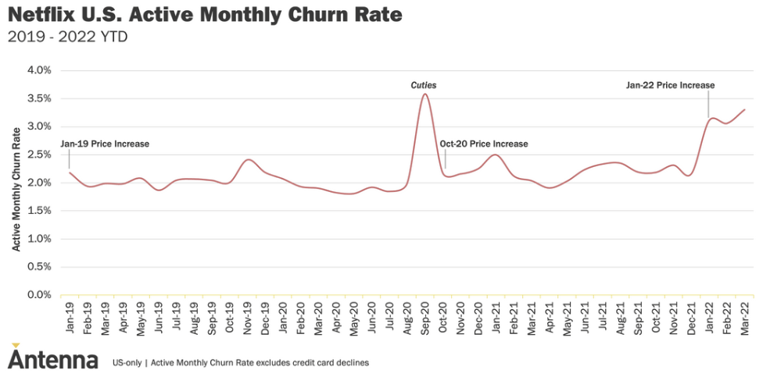

##### **Figure 18:** `Netflix U.S. Active Monthly Churn Rate`

**Churn Rate Analysis**

An examination of the **Netflix U.S. Active Monthly Churn Rate** timeline reveals a highly responsive relationship between platform pricing adjustments and subscriber churn. Netflix schedules its subscription tariff hikes either directly adjacent to the New Year window, as documented in **January 2019** and **January 2022**, or during the immediate autumn ramp-up period leading into the fourth quarter, evidenced by the **October 2020** price hike.

The data show that these fee increases trigger a corresponding upward trajectory in customer churn. For instance, the **January 2022** price increase catalysed a sharp attrition period, driving active monthly churn from a stable **2.0%-2.5%** up to **3.3%** by **March 2022** (Antenna, 2025). This cyclical trend provides a vital strategic rationale for the "New Year Loading" phenomenon previously observed; Netflix intentionally concentrates a large volume of premium content drops on **December 31st** and **January 1st** to artificially elevate its immediate value, serving as a customer churn buffer explicitly introduced to neutralise the churn triggered by subscription fee inflation.

**Outlier Mitigation**

This timeline highlights a single, devastating spike in **September 2020**, where active monthly churn exploded to a historic peak of **3.6%**. This steep escalation was completely detached from pricing modifications and operated instead as a direct consequence of severe consumer backlash following the controversial marketing and release of the French film *Cuties*. According to industry data published by Variety, domestic cancellations in the United States rapidly accelerated to **eight times the platform's baseline daily rate** as public outrage triggered a massive viral boycott. Netflix subsequently issued a formal apology for a promotional poster that displayed the young dance cast in provocative poses, withdrawing the asset after admitting the artwork was "inappropriate" and unrepresentative of the film (Spangler, 2020).

#### **5.3.3 Formulation of Hypotheses**

**Limitations**
1. **Geographic Alignment:** The churn metrics are exclusively isolated to the United States market. To preserve statistical rigour, the independent factor (content release volume) will be filtered to focus entirely on domestic US output.

2. **Temporal Synchronisation:** Only two full calendar years of the 39-month churn dataset coincide with the primary catalogue dataset. Consequently, analysis will be strictly bounded to this overlapping interval.

##### **Step 1:** Hypothesis & Significance Level

The One-Way ANOVA test is defined as follows:
- **$H_0$ (Null Hypothesis):** The volume of content additions has no effect on customer retention. The mean subscriber churn rate is equal across months categorised by low, medium, and high release volumes ($\mu_{Low} = \mu_{Med} = \mu_{High}$).

- **$H_1$ (Alternative Hypothesis):** The volume of content additions significantly impacts customer retention. At least one release volume tier results in a distinct mean subscriber churn rate ($\mu_i \ne \mu_j$ for at least one pair of output tiers ($i \ne j$)).

This construction provides formal validation for whether the heavy, reactionary front-loading of the platform has any genuine effect in reducing the amount of customer attrition. By testing for significant variance across these volume cohorts, the model determines if aggressive catalogue deployment successfully alters subscriber behaviour during high-attrition periods or if churn remains fundamentally indifferent to output volume.

#### **5.3.4 Statistical Application**

Prior to inferential testing, a table was constructed to align the independent and dependent variables through the following systematic pipeline:
1. **Release-Churn Causal Mapping:** Quantitative monthly churn metrics were extracted from the Antenna intelligence timeline and paired with the isolated domestic US content release volumes. To ensure the hypothesised cause of release volume precedes the effect of churn rate in time, a single-period time lag was introduced to the churn vector. Consequently, the release data window was extended by a single observation, to include **December 2018**, establishing a rigorous causal mapping: **December 2018** output influences **January 2019** customer attrition, **January 2019** output influences **February 2019** customer attrition, proceeding in the same fashion over the 24-month overlapping period.

2. **Boundary Optimisation:** Initial categorisation of the independent variable utilised boundaries $\mu \pm 0.5\sigma$ separating **Low**, **Medium**, and **High**. However, this approach yielded *$p$-values* for the **Shapiro-Wilk** and **Levene's** tests dangerously close to the significance level ($\alpha = 0.05$). Instead, opting for **Medium** to be contained within the interval $55 \lt \text{Medium} \lt 70$ ($\text{Low} \le 55$ and $\text{High} \ge 70$) maintained similar class balances to the initial cohorts while returning a *$p$-value* that comfortably exceed the significance level, successfully failing to reject the null hypotheses required for a valid One-Way ANOVA.

In [296]:
netflix_churn = pd.DataFrame({"Churn": [
    2.20, 1.95, 1.95, 2.00, 2.10, 1.88, 2.05, 2.08, 2.05, 2.00, 2.42, 2.20,
    2.10, 1.93, 1.90, 1.83, 1.81, 1.92, 1.85, 1.90,       2.40, 2.12, 2.20,
    2.5
    ]})

df_months = df_months[df_months.Country == "United States"]
df_months = (
    df_months.groupby(["Release_Month", "Release_Year"])["Show_Id"].count()
    .reset_index(name="Count"))

In [297]:
sub_df = df_months[(df_months.Release_Year.isin([2018, 2019, 2020]) == True)].reset_index(drop=True)

# ordering by year then month
sub_df = pd.concat([sub_df[0::3], sub_df[1::3], sub_df[2::3]]).reset_index(drop=True)

# discarding all 2018 months besides December
sub_df = sub_df[11:]

sub_df = pd.concat([sub_df[0:21], sub_df[22:]]).reset_index(drop=True) 
sub_df["Volume"] = sub_df.Count.apply(lambda x: 'High' if x > 70 else ('Medium' if x > 55 else 'Low'))

table = pd.concat([sub_df.Release_Year, sub_df.Release_Month, sub_df.Count, sub_df.Volume, netflix_churn], axis=1)
table

,Release_Year,Release_Month,Count,Volume,Churn
0,2018,Dec,57,Medium,2.20
1,2019,Jan,52,Low,1.95
2,2019,Feb,46,Low,1.95
3,2019,Mar,57,Medium,2.00
4,2019,Apr,46,Low,2.10
5,2019,May,41,Low,1.88
6,2019,Jun,56,Medium,2.05
7,2019,Jul,69,Medium,2.08
8,2019,Aug,52,Low,2.05
9,2019,Sep,60,Medium,2.00


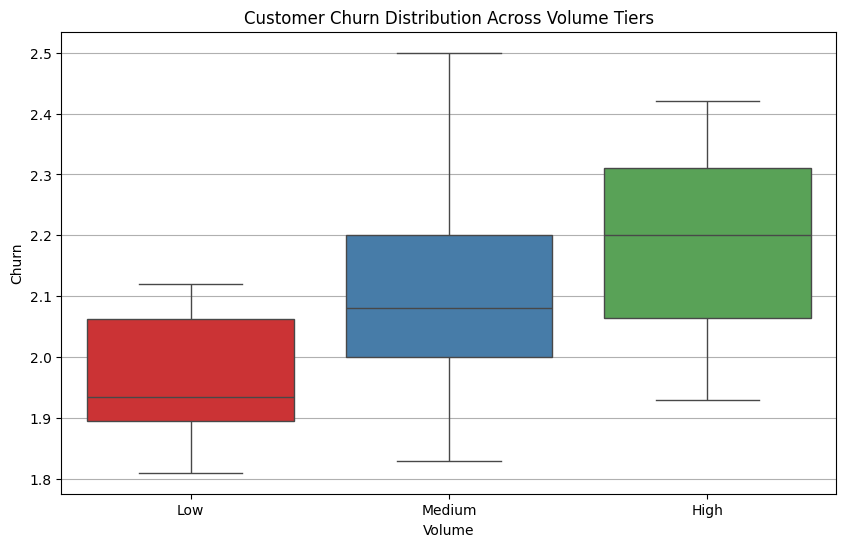

In [298]:
plt.figure(figsize=(10, 6))
sns.boxplot(table,
            x="Volume", y="Churn",
            order=["Low", "Medium", "High"],
            palette='Set1')

plt.title("Customer Churn Distribution Across Volume Tiers")
plt.grid(axis='y')
plt.show()

##### **Figure 19:** `US Active Monthly Churn Profile by Volume Classifications`

**The Anticipatory Increase in Attrition:** The distribution of time-lagged customer churn across the **Low**, **Medium**, and **High** release cohorts reveal a positive correlation between catalogue expansion and active monthly churn. Instead of mapping high content volumes to a suppressed attrition period, the data demonstrate an incremental upward shift in median value. The median churn rate climbs from **~1.92-1.94%** in Low-output months, to **~2.07-2.09%** during Medium-output periods, and peaks at **~2.20%** at High-output periods. This pattern provides strong empirical validation for Netflix's anticipatory scheduling regime, deliberately concentrating its highest rate of content deployment during high-attrition windows, using dense content drops to actively counter pre-planned price hikes and predictable subscriber loss phases.

In [299]:
low = table[table.Volume == "Low"].Churn.tolist()
med = table[table.Volume == "Medium"].Churn.tolist()
high = table[table.Volume == "High"].Churn.tolist()

In [300]:
print("-- Sample Means --")
print(f"Mean of 'Low' cohort:     {round(np.mean(low), 3)}")
print(f"Mean of 'Medium' cohort:  {round(np.mean(med), 3)}")
print(f"Mean of 'High' cohort:    {round(np.mean(high), 3)}")

-- Sample Means --
Mean of 'Low' cohort:     1.961
Mean of 'Medium' cohort:  2.14
Mean of 'High' cohort:    2.183


**Note:** The formula for sample variance is as follows

$$
s^2 = \frac{\sum(x_i - \hat{x})^2}{n-1}
$$

Therefore, in the code block below, `ddof=1` is taken as a parameter within function `np.var`, referring to a singular degree of freedom that results in the use of denominator $n-1$ required for the sample variance equation.

In [301]:
print("-- Sample Variances --")
print(f"Variance of 'Low' cohort:     {round(np.var(low, ddof=1), 3)}")
print(f"Variance of 'Medium' cohort:  {round(np.var(med, ddof=1), 3)}")
print(f"Variance of 'High' cohort:    {round(np.var(high, ddof=1), 3)}")

-- Sample Variances --
Variance of 'Low' cohort:     0.011
Variance of 'Medium' cohort:  0.044
Variance of 'High' cohort:    0.06


**Output Volume Dispersion:** The variances across the three volume categories uncover the limits and behaviour of this retention tactic. The **Low** volume tier exhibits little variation in attrition, at **0.011**, exposing that customer churn remains stable during quiet deployment periods. Conversely, dispersion scales drastically within the **Medium** output tier, where the variance is quadruple the **Low** variance at **0.044** and is bounded between a minimum of **1.83%** and a maximum of **2.5%**.

##### **Step 2:** Shapiro-Wilk Test for Normality

In [302]:
_, shapiro_p_value_low = stats.shapiro(low)
_, shapiro_p_value_med = stats.shapiro(med)
_, shapiro_p_value_high = stats.shapiro(high)

In [303]:
print(shapiro_p_value_low)
print(shapiro_p_value_med)
print(shapiro_p_value_high)

0.19361932501855644
0.6986611382961514
0.8876138012137402


The Shapiro-Wilk test for normality yielded *$p$-values* of **0.194**, **0.699**, **0.888** across the three respective volume categories. Because all values comfortably exceed the significance threshold of $\alpha = 0.05$, this leads to a unanimous failure to reject the null hypothesis. Consequently, all three groups have successfully passed the test for normality, satisfying one of the three assumptions for One-Way ANOVA evaluation.

##### **Step 3:** Levene's Test for Equal Variances

In [304]:
_, levene_p_value = stats.levene(low, med, high)

In [305]:
print(levene_p_value)

0.25980119331068013


Levene's test yielded a *$p$-value* of **0.260**. As this result also comfortably exceeds the standard prescribed significance threshold of $\alpha = 0.05$, this leads to a failure to reject the null hypothesis. It is therefore confirmed that the dataset possesses statistically similar variances across all categories, successfully clearing the homogeneity of variance assumption required for the One-Way ANOVA.

##### **Step 4-9:** $F$-statistic & *$p$-value*

**Disclaimer:** The values for $SSB$ and $SSW$ are not displayed and are however calculated using the `stats.f_oneway()` function to immediately retrieve the F-statistic and *$p$-value* of the One-Way ANOVA.

In [306]:
aov = pg.anova(table, dv='Churn', between='Volume')
aov[["F", "p_unc"]]

,F,p_unc
0,3.898495,0.036321


The execution of the One-Way ANOVA test yielded an $F$-statistic of **3.898** and a corresponding *$p$-value* of **0.036**. Because the *$p$-value* falls strictly below the designed significance threshold of $\alpha = 0.05$, the null hypothesis ($H_0$) is formally rejected. This outcome establishes that the variations between the calculated group means are statistically significant and cannot be attributed to random sampling fluctuations. 

##### **Step 10:** Eta-Squared ($\eta^2$)

In [307]:
aov["np2"]

0    0.270757
Name: np2, dtype: float64

Following the One-Way ANOVA, the calculation of the effect size (analogous to Cramer's $V$ for the Chi-Square test) yielded an Eta-Squared ($\eta^2$) value of **0.27**. This metric indicates that the independent categorical variable of Volume accounts for exactly **27%** of the total variance within the continuous dependent variable. According to the benchmarks for interpreting the values for Eta-Squared, a value of **0.27** is classified as a large effect size. This quantifies a robust and substantial magnitude of relationship between the Volume and Churn Rate.

##### **Step 11:** Drawing a Conclusion & Inference Analysis

In [308]:
100*table.Volume.value_counts(normalize=True)

Volume
Low       50.0
Medium    37.5
High      12.5
Name: proportion, dtype: float64

**1. Methodology Robustness & Categorisation Strategy**

The segmentation of Netflix's monthly release volume using distinct boundaries yields a deliberate distribution of of **Low** (**50.0%**), **Medium** (**37.5%**), and **High** (**12.5%**) output tiers. Although this distribution presents a structural imbalance, that heavily leans towards the lower output end, iterative testing and boundary tuning proved this specific grouping to be the most statistically reliable configuration. Rather than forcing arbitrary, equally sized bins that would distort the operational reality of Netflix's release cycles, this categorisation preserves the distinct characteristics of the platform's deployment strategies. As a result, these well-defined classes successfully cleared both the Shapiro-Wilk test for normality and Levene's test for the homogeneity of variance.

**2. Statistical Significance & Real-World Context**

With a calculated *$p$-value* of **0.036**, the One-Way ANOVA formally rejects the null hypothesis ($H_0$) is formally rejected in favour of the alternative hypothesis ($H_1$). This confirms that the volume of content added to the platform does indeed exert a statistically significant influence on monthly subscriber churn.

However, the true commercial insight lies in the magnitude of this relationship. The calculated Eta-Squared ($\eta^2$) value of **0.27** reveals that release volume alone accounts for a remarkable **27% of the total variance in monthly churn**. Despite a compact 24-month sample size, which naturally supresses statistical power, an effect size of this magnitude proves that content scaling is a primary driver of subscriber retention.

**3. Strategic Implications for Netflix's Output Regime**

**3.1. Necessity of High-Output Month:**

The **High** release volume tier is rare, accounting for a mere **12.5%** of the observed timeline. This scarcity reflects a highly calculated release strategy, as Netflix cannot indefinitely sustain high output due to strict capital and production constraints. Instead, the platform strategically concentrate massive content drops into specific seasonal windows, most notably leading up to and surrounding the New Year period, to act as a hard brake on customer attrition. 

The striking proximity of the mean churn rates across **Medium** (**2.14%**) and **High** (**2.183%**) cohorts reveals a clear threshold of diminishing returns. Flooding the catalogue to achieve a **High** volume classification does not drive attrition down indefinitely, but rather, is a deployment strategy that acts as a stabiliser for mitigating churn to the baseline level of **Medium** release periods during times of peak attrition.

**3.2. The Baseline Defensive Buffer (By Design)**

The remaining **87.5%** of the dataset is split between **Low** (**50.0%**) and **Medium** (**37.5%**) output tiers. As demonstrated in **Figure 19**, the **Low** volume cohort yields the absolute fewest churners across the entire dataset, maintaining a low sample mean of **1.961%** and a highly compressed sample variance of **0.011**. This minimal variance indicates that subscriber behaviour during these periods is exceptionally stable, consistent, and predictable.

Rather than indicating that outputting less content somehow leads to more content subscribers, this trend is entirely "by design". Netflix's scheduling regime is highly predictive: during low-risk seasonal windows, when subscriber engagement is naturally high and organic attrition is anticipated to remain low, the platform deliberately downscales its content output. By reserving capital during these low-variance periods, Netflix avoids unneccesarily exhausting its production budget on an audience that it already highly retained.

However, as seasonal churn risks begin to climb, subscriber behaviour becomes far more volatile. This shift is reflected as Netflix systematically ramps up output to the **Medium** (variance: **0.044**) and eventually **High** (variance: **0.060**) tiers. The ballooning variances in these higher cohorts demonstrate the unpredictable, high-risk nature of the periods in which they are deployed. Netflix is forced to accept higher and more volatile churn in these windows, proactively releasing content to act as s vital stabilisation strategy. Thus, the **Low**-volume months serve as a highly efficient defensive buffer, allowing Netflix to optimise capital allocation during quiet periods so they can afford to defend the platform when attrition risks spike.

**3.3. Acquisition & Retention**

Crucially, this output regime serves a dual purpose. While the ANOVA proves that massive catalogue expansion actively mitigates active subscriber churn, these highly publicised content spikes simultaneously provide substantial non-customer value. The encouragement of both dormant users to renew and entirely new demographics to subscribe, with help of the ever globally expanding catalogue, establishes the high-volume output spike as Netflix's primary growth driver.

### **5.4 Hypothesis 5:** Family-Oriented Prioritisation

#### **5.4.1 Statistical Methodology Overview**

As conducted in sections **5.1** and **5.2**, a Chi-Square test of independence was executed to investigate whether Netflix intends on tailoring its content release toward younger audiences and families. A contingency table cross-tabulating the categorical variables `Release_Year` (2019 vs. 2020) and `Content_Maturity` (Mature vs. Family) was constructed to evaluate this potential demographic shift. This analysis utilises the familiar two-step inference process of a **Pearson's Chi-Squared Test of Independence**, followed by a **Cramer's $V$**.

#### **5.4.2 Hypothesis Formulation**

The test is as follows:

- **$H_0$ (Null Hypothesis):** The volume of content releases by maturity rating (Mature vs. Family) is independent of the year of release (**2019 vs. 2020**).

- **$H_1$ (Alternative Hypothesis):** The volume of content releases by maturity rating is dependent on the year of release.

A significance level $(\alpha)$ of $5 \% \space (\alpha = 0.05)$ was chosen for this test.

#### **5.4.3 Statistical Application**

In [309]:
df_family_ratings = df_family_ratings[df_family_ratings.Release_Year.isin([2019, 2020]) == True]

df_family_ratings['Content_Maturity'] = (
    np.where(df_family_ratings.Rating == 'TV-MA',
             "Mature", "Family"))

##### 1. **Contingency Table Formulation**

In [310]:
contingency_table = pd.crosstab(df_family_ratings.Content_Maturity, df_family_ratings.Release_Year)
contingency_table

Release_Year,2019,2020
Content_Maturity,,
Family,458,502
Mature,794,713


##### 2. **$\chi^2$ Test Statistic, *$p$-value* & Cramer's $V$**

In [311]:
chiSquare_cramerV(contingency_table)

Chi-Square test statistic: 5.62, with 1 degree of freedom and p-value: 0.01776

Cramer's V: 0.0477


#### **5.4.4 Hypothesis 2: Inferential Analysis & Effect Size Implication**

##### **Chi-Square Test Statistic & *$p$-value***

Considering the agreeance between Chi-Square and *$p$-value*:
1. The Pearson's Chi-Square $(\chi^2)$ test of independence yielded a test statistic of $5.62 > 3.841$ and therefore falls within the critical region, and,
2. The *$p$-value* extracted from the contingency table of $0.0178 < 0.05$, substantially lower than the chosen $5 \%$ significance level.

Consequently, the null hypothesis $(H_0)$, which claims that content by rating additions are entirely independent of the release year, is formally rejected, with both the Chi-Square test statistic and the *$p$-value* confirming this. The alternative hypothesis $(H_1)$ is accepted, validating that the volume shift observed between **2019** and **2020** represents a statistically sufficient strategic change.

##### **Effect Size Evaluation via Cramer's $V$**

The calculated Cramer's $V$ (Cohen's $w$) yielded an effect size of **0.0477**. As stated in section **5.3**, given $0.0477 < 0.1$, the value of Cramer's $V$ is below the small effect threshold, indicating an exceptionally weak relationship strength. While the *$p$-value* uncovers a statistically significant association, Cramer's $V$ reveals that this shift in target audience is incredibly subtle. This divergence is, just as in section **5.1**, a direct byproduct of large sample size inflation, where a massive data pool artificially drives down the *$p$-value* for even the most minor variations.

---
<a id="conc"></a>
## **6. Key Insights & Conclusion**

### **6.1 Hypotheses Outcomes**

#### **6.1.1 Hypothesis 1:** Netflix is halting its content output velocity following the 2019 peak to mitigate the risks of platform oversaturation.

**1. Netflix's Year-on-Year Scheduling Strategy**

The empirical evidence indicates that the **post-2019** content deceleration was the result of external operational shocks rather than a deliberate strategic retreat to avoid platform oversaturation. The output contractions observed in **2020** were fundamentally driven by the **COVID-19 pandemic**, where strict social distancing mandates, travel-bans, and "no mixing" restrictions crippled global content production.

TV show production had dropped from **532** in **2019** to **493** in **2020**. Because these delayed projects were forced to shift their filming schedules downstream, Netflix suffered a subsequent **12%** drop in the number of **Netflix Original shows** on its books by the early months of **2021**. Film production experienced an even more severe logistical bottleneck; global lockdowns caused the volume of ready-for-release movies to plummet from **987** in **2019** to just **338** in **2020** assets stood idle worldwide (Scott Fleary, 2022).

**2. Regional Year-on-Year Volume Expansion**

Crucially, catalogue data proves that Netflix never intended to maintain a long-term content contraction. As demonstrated in **Figure 20: Netflix Library Numbers YOY**, total library footprints across the US, Australia, Canada, and the UK expanded consecutively year-on-year from **2019** through **2021**. Rather than throttling its output pipeline, Netflix leveraged this period to transition towards a highly diversified, all-audiences business model, steadily scaling its regional asset allocations to capture broader international segments, solidifying itself as a staple, "household essential" (Moore, 2022).

![alt text](Netflix-Library-Numbers-YOY.png)

This expansion-centric strategy is further reinforced by the aggressive acceleration of first-party intellectual property. As illustrated in **Figure 21: Netflix Original Films Released in the US (2015-2021)**, the volume of feature films rose from **159** titles in **2019** to **203** in **2020**, and peaking at **257** in **2021**. Notably, this growth was primarily anchored by international production hubs, which expanded from **98** in **2019** to **188** in **2021**. This highlights a calculated push to capture uncharted global markets rather than a fear of catalogue crowding and fatigue (Moore, 2022).

![alt text](netflix-originals-released-in-2021-chart.png.webp)

The data formally refutes the oversaturation narrative central to **Hypothesis 1**. The platform was not oversaturated; instead, Netflix recognised an opportunity to capitalise on unexplored geographic markets and shifting household demographics. The temporary dip in **2020** was an anomaly dictated by global pandemic restrictions, masked by a long-term strategy of year-on-year volume increases and portfolio expansion.

#### **6.1.2 Hypotheses 2 & 5**

**1. Significance vs. Scale**

Inferential testing for both hypotheses revealed distinct variations in the magnitude and scale of these two portfolio adjustments, though both represent statistically significant structural shifts, the TV show pivot (**Hypothesis 2**) analysis yields an exceptionally high degree of statistical significance ($p = 0.0000053$) paired with a small-to-medium effect size (Cramer's $V = 0.1212$). This confirms a clear visible realignment in production priorities. Crucially, industry evidence confirms that this pivot was a reactive operational response to the pandemic, rather than a deliberate, pre-scheduled long-term programming tactic. During worldwide lockdowns, consumer demand shifted as millions of homebound individuals adopted long-form episodic content as a vital coping mechanism to combat isolation and ennui. Media channels routinely prescribed TV series to "soothe quarantine blues", and Netflix capitalised on its fundamental brand alignment with episodic, immersive storytelling to provide a powerful sense of public connection and collective togetherness during a global crisis (Horek, 2021).

In contrast, the Family-Oriented Pivot (**Hypothesis 5**) represents a much weaker trend ($p = 0.0177645$) with a negligible effect size (Cramer's $V = 0.0477$). This indicates that the expansion into youth and co-viewing demographics is a somewhat targeted layer within the catalogue rather than a structural overhaul. Netflix secures this specific demographic footprint through systemic onboarding and ecosystem features, such as automatically generating a dedicated "Kids" profile by default upon account registration. This paired with empirical research into family viewing needs, cross-generational content selections like natural history documentaries designed for co-viewing, and off-platform engagement initiatives like the physical *Netflix Family* magazine (Netflix, 2026).

**2. Expansion vs. Substitution**

The structural contrast between these effect sizes demonstrates that neither initiative operates as a substitution strategy. Netflix is not abandoning feature films to become a purely television-driven network, nor is it dismantling its mature library to become an exclusively family-friendly platform.

Instead, these dynamics reflect a comprehensive expansion model intentionally engineered to mitigate subscriber churn and maximise engagement. Netflix's core framework explicitly rejects demographic-driven profiling, deploying a content-agnostic recommendation system to capture a broad spectrum of user preferences. To prevent platform fatigue, the leading catalyst for subscription cancellations, the recommendation engine dynamically tracks user interaction history, continually deprioritising older selections by heavily weighting recent viewing choices to keep user interfaces refreshed and highly individualised (Netflix, 2026).

The significant pivot toward TV series allowed the platform to fulfill the sudeen, lockdown-driven demand for episodic runtime without freezing its original film-centric output regime. Simultaneously, the subtle growth in family classifications successfully captured household-level co-viewing groups while maintaining a dominant volume of adult-centric programming.

Consequently, **Hypotheses 2** and **5** are rejected as complete replacement strategies. The statistical and operational realities demonstrate that Netflix's true overarching objective is to benefit from all major markets and demographics simultaneously. Rather than substituting outright, the platform uses targeted, varying degrees of volume acceleration alongside real-time algorithmic updates to build a universally indispensable global catalogue.

#### **6.1.3 Hypothesis 3:** Netflix strategically increases content output around the New Year holiday as a retention tactic to mitigate subscriber churn.

**1. The 2020 Front-Loading Countermeasure**

Exploratory Data Analysis (EDA) reveals that Netflix heavily front-loaded content drops in early January to combat seasonal subscriber churn (Figure 4). Despite the data displaying an overall reduction in content volume, from **2,154** releases in **2019** and **2,010** releases in **2020** (Figure 3), early January releases spiked dramatically. The release ratios for the first versus the second half of January shifted from just under **2:1** in **2019** to above **3:1** in **2020**, representing an increase of over **63%** in early January drops. This shift was a direct, tactical response to a major business crisis: in **Q2** **2019**, Netflix had lost **130,000 US subscribers** following a controversial price increase (Netflix, 2019). Dumping a massive wave of 173 titles in early **January 2020** was a defensive manoeuvre to suppress cancellations, artificially inflating the platforms' perceived value right when winter viewing peaked.

**2. The Post-2020 Pivot**

However, flooding the platform with massive, front-loaded content blocks quickly became financially unsustainable. The limits of this volume-led strategy were completely exposed during the 2022 churn crisis, when Netflix lost a combined **1.2 million subscribers** across **Q1** and **Q2**, causing its stock price to plummet by **35%** (Helmore, 2022; Netflix, 2022a; Netflix, 2022b). Instead of doubling down and utilising content volume to retain price-sensitive users, Netflix launched a cheaper, ad-supported tier in **November 2022** (Netflix, 2022b). Introducing a lower entry price successfully managed customer retention, meaning the platform no longer needed to rely on volatile winter content spike to keep budget-conscious users from leaving.

**3. Current Scheduling**

Modern scheduling patterns confirm that Netflix has successfully transitioned to a much leaner and cost-effective approach to content distribution. Rather than funding expensive waves of new original productions to fill the winter gap, New Year scheduling now relies heavily on dropping older cinematic releases, with a handful with **pre-2000** release dates such as Twins, Wild Things, and My Girl to name a few (Moore, 2025). High-budget first-party investments are now deployed tactically rather than in abundance. The platform benefits from a single, highly anticipated drop event, such as a blockbuster series finale on New Year's Eve, to capture massive cultural attention and lock in holiday engagement without the need for high overall production volume (Moore, 2025).

Ultimately, **Hypothesis 3** is accepted, with proof in the form of clear historical implementation but rejected as a viable year-on-year strategy. While Netflix previously relied on heavy content front-loading to defend its market share against immediate subscriber losses (Netflix, 2019), this unsustainable tactical reaction has been phased out. By combining budget-friendly ad-supported subscription tiers, low-cost licensed library assets, and targeted blockbuster events, the platform now drives long-term retention through structural value rather than volatile seasonal content dumps.

### **6.2 Limitations**

**1. Current Dataset & Strategic Blind Spots**

While the current dataset provides a snapshot of Netflix's historical release volumes, it possesses data boundaries that limit a complete evaluation of the platform's long-term asset value. Expanding upon these limitations reveals critical strategic blind spots.

**2. Licensing Data Void**

The dataset lacks explicit information regarding licensing durations, renewal rates, and acquisition costs. In the streaming landscape, content utility is heavily dictated by contract lifespans. Netflix frequently executes bulk-licensing agreements with singular media conglomerates (such as Sony or Warner Bros. Discovery) to secure temporary, multi-title streaming windows (Netflix, 2026; Moore, 2026).

Without access to these operational timelines, it is difficult to evaluate:

- **Catalogue Durability vs. Decay:** A high volume of additions may mask a simultaneous offloading of expiring titles, skewing perceived catalogue growth.

- **Rewatchability Value:** The true relevance of a title to subscriber retention is often tied to its permanence. Log-term library anchors drive passive and continuous rewatchability, whereas short-term licensed assets serve as fleeting, seasonal engagement spikes.

- **Asset Portfolio Balance:** The data cannot discern between high-cost licensed anchors and lost-cost, speculative filler content, obscuring how Netflix optimises its content spend to mitigate churn.

**3. The Regional Fragmentation Reality**

A significant limitation is the absence of viewing restrictions and geo-blocking data. Content availability is highly fragmented by territory due to regional popularity and legacy broadcast rights (Netflix, n.d.).

Analysing the catalogue as a single, homogenous global entity introduces analytical friction:

- **Masked Churn Dynamics:** A localised spike in subscriber attrition (e.g., in the US market) might be driven by the expiration of a major regional license (records of which are unaccounted for in this dataset).

- **Distorted Strategic Intent:** Volume expansion patterns may be misread as global corporate strategies when they are instead hyper-localised interventions designed to comply with regional content quotas or to capture specific emerging market demographics.

### **6.3 Future Analysis Considerations**

#### **Predictive & Architectural Modelling for Future Analysis**

**1. Time-Series Forecasting (ARIMA/SARIMAX)**

To move beyond retrospective descriptive analysis, future iterations of this analysis could implement predictive time-series modelling. Specifically, Autoregressive Integrated Moving Average (ARIMA) and Seasonal ARIMA with exogenous variables (SARIMAX) models can capture complex quarterly seasonality and non-linear trends in subscriber acquisition and churn. By integrating exogenous indicators, such as competitor release schedules, subscription price adjustments, and macroeconomic/behavioural factors, SARIMAX modelling would allow the forecasting of the direct impact of seasonal content front-loading on net subscriber additions with greater statistical precision (Hyndman and Athanasopoulos, 2021).

**2. Natural Language Processing (NLP)**

Relying strictly on categorical metadata (such as "Drama" or "Comedy") overlooks subtle shifts in thematic development. Implementing text-mining algorithms, such as Latent Dirichlet Allocation (LDA) or Bidirectional Encoder Representations from Transformers (BERT), to ingest text descriptions of titles can unlock hidden thematic insights.

- **Application:** By extracting the most statistically common keywords and emotional weights from text descriptions, the model can track shifting narrative trends over time.

- **Insight Extraction:** This would allow the verification of whether Netflix is actively pivoting towards specific psychological hooks (e.g., "dystopian, "nostalgia", "true-crime investigation") to drive engagement during periods of socio-economic stress, providing a clearer picture of audience relevance without needing internal viewing metrics.

---
<a id="ref"></a>
## **7. References**

Abdul Rahman H, Noraidi AA, Hj Khalid AN, Mohamad-Adam AZ, Zahari NH, Tuming NE. (2025) *Practical guide to calculate sample size for Chi-Square test in biomedical research. BMC Med Res Methodol. 2025;25(1):144. Published 2025 May 26. doi:10.1186/s12874-025-02584-4.* Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC12107878/ (Accessed: 31 May 2026)

Antenna. *Netflix Q1'22 Retrospective.* Available at: https://www.antenna.live/insights/netflix-q122-retrospective (Accessed: 5 June 2026)

Bergh D. (2025) *Chi-Square Test of Fit and Sample Size-A Comparison between a Random Sample Approach and a Chi-Square Value Adjustment Method. J Appl Meas. 2015;16(2):204-17. PMID: 26075668.* Available at: https://pubmed.ncbi.nlm.nih.gov/26075668/ (Accessed: 30 May 2026)

Berman J. (2020) *8 Takeaways From the Streaming Wars' Biggest, Weirdest Year Yet, Time Magazine.* Available at: https://time.com/5922040/streaming-wars-2020/ (Accessed: 29 May 2026)

Bitran T. (2022) *Skip Intro: Netflix Turns 25 Today, Tudum By Netflix.* Available at: https://www.netflix.com/tudum/articles/netflix-trivia-25th-anniversary (Accessed: 29 May 2026)

Bobbitt Z. (2021) *How to Perform an ANOVA with Unequal Sample Sizes.* Available at: https://www.statology.org/anova-unequal-sample-size/ (Accessed: 6 June 2026)

Bobbitt Z. (2021) *What is Eta Squared (Definition & Example).* Available at: https://www.statology.org/Eta-Squared/ (Accessed: 8 June 2025)

Cain S. (2022) *Netflix is introducing a new subscription with ads. Here's what you need to know, The Guardian.* Available at: https://www.theguardian.com/media/2022/oct/14/netflix-basic-with-ads-launches-new-cheaper-subscription-tier-ad-supported-heres-what-you-need-to-know (Accessed: 28 May 2026)

Dougert A. (2025) *Netflix puts 12% more ads in its originals than its licensed titles, Ampere Analysis.* Available at: https://www.ampereanalysis.com/insight/netflix-puts-12-more-ads-in-its-originals-than-its-licensed-titles (Accessed 28 May 2026)

Ferguson C J. (2009) *An Effect Size Primer: A Guide for Clinicians and Researchers.* Available at: https://www.christopherjferguson.com/Ferguson%20PPRP.pdf (Accessed: 30 May 2026)

Frost J. *Eta Squared [$\eta^2$].* Available at: https://statisticsbyjim.com/glossary/Eta-Squared/ (Accessed: 6 June 2026)

Helomore E. (2022) *Netflix Shares fall more than 35% after streamer loses over 200,000 subscribers.* Available at: https://www.theguardian.com/media/2022/apr/20/netflix-shares-fall-losing-subscribers (Accessed on 20 June 2026)

Horek T. (2021) *"Netflix and Heal": The Shifting Meanings of Binge-Watching during the COVID-19 Crisis.* Available at: https://online.ucpress.edu/fq/article/75/1/35/118489/Netflix-and-Heal-The-Shifting-Meanings-of-Binge (Accessed: 15 June 2026)

Hyndman R J, Athanasopoulos G. (2021) *Forecasting: Principles and Practice (3rd ed).* Available at: https://otexts.com/fpp3/ (Accessed: 26 June 2026)

Laerd Statistics. *One-way ANOVA.* Available at: https://statistics.laerd.com/statistical-guides/one-way-anova-statistical-guide.php (Accessed: 5 June 2026)

M Rahul Vyas. *Netflix Movies and TV Shows.*  Available at: https://www.kaggle.com/datasets/rahulvyasm/netflix-movies-and-tv-shows (Accessed: 4 January 2026)

Malato G, Whitfield B. Built In. (2025) *An Introduction to the Shapiro-Wilk Test for Normality.* Available at: https://builtin.com/data-science/shapiro-wilk-test (Accessed: 5 June 2026)

McHugh ML. (2023) *The Chi-Square test of independence. Biochem Med (Zagreb). 2013;23(2):143-9. doi: 10.11613/bm.2013.018. PMID: 23894860; PMCID: PMC3900058.* Available at: https://pubmed.ncbi.nlm.nih.gov/23894860/ (Accessed: 30 May 2026)

MedCalc. *Values of the Chi-Square distribution.* Available at: https://www.medcalc.org/en/manual/chi-Square-table.php (Accessed: 31 May 2026)

Minitab. (2016) *Understanding Analysis of Variance (ANOVA) and the F-test.* Available at: https://blog.minitab.com/en/blog/adventures-in-statistics-2/understanding-analysis-of-variance-anova-and-the-f-test (Accessed: 6 June 2026)

Moore K. (2022) *Netflix Library By The Numbers 2021.* Available at: https://www.whats-on-netflix.com/news/netflix-library-by-the-numbers-2021/ (Accessed: 8 June 2026)

Moore K. (2025) *What's Coming to Netflix This Week: December 29th to January 4th, 2026, What's on Netflix.* Available at: https://www.whats-on-netflix.com/coming-soon/whats-coming-to-netflix-this-week-december-29th-to-january-4th-2026/ (Accessed: 28 May 2026)

Moore K (2026). *Warner Bros. Television Opens Up The Licensing Floodgates To Netflix As Acquisition.* Available at: https://www.whats-on-netflix.com/news/warner-bros-television-opens-up-the-licensing-floodgates-to-netflix-as-acquisition-moves-forward/ (Accessed: 22 June 2026)

Netflix. (2019) *Letter to Shareholders: Q1 2019. Netflix Investor Relations.* Available at: https://s22.q4cdn.com/959853165/files/doc_financials/quarterly_reports/2019/q2/Q2-19-Shareholder-Letter-FINAL.pdf (Accessed on 20 June 2026)

Netflix. (2021) *Written evidence submitted by Netflix.* Written evidence submitted to the House of Commons Culture, Media, and Sport Committee. Available at https://committees.parliament.uk/publications/53105/documents/297153/default/ (Accessed: 15 June 2026)

Netflix. (2022a) *Letters to Shareholders: Q1 2022. Netflix Investor Relations.* Available at: https://s22.q4cdn.com/959853165/files/doc_financials/2022/q1/FINAL-Q1-22-Shareholder-Letter.pdf (Accessed 20 June 2026)

Netflix. (2022b) *Letters to Shareholders: Q2 2022. Netflix Investor Relations.* Available at: https://s22.q4cdn.com/959853165/files/doc_financials/2022/q2/FINAL-Q2-22-Shareholder-Letter.pdf (Accessed 20 June 2026)

Netflix. (2026) *Netflix and Sony Pictures Entertainment Enter New Pay-1 Deal With First-of-its-Kind Global Reach.* Available at: https://about.netflix.com/en/news/netflix-and-sony-pictures-entertainment-enter-new-global-pay-1-deal (Accessed: 22 June 2026)

Netflix. *Why isn't a TV show or movie available in your country?* Available at: https://help.netflix.com/en/node/125345 (Accessed: 26 June 2026)

Ofcom. (2020) *Effects of Covid-19 on online consumption, Ofcom.* Available at: https://www.ofcom.org.uk/siteassets/resources/documents/research-and-data/tv-radio-and-on-demand-research/covid-19-news-and-information-consumption-attitudes-and-behaviour/week-ten/covid-19-news-consumption-week-ten-comscore.pdf?v=324910 (Accessed: 28 May 2026) 

Scott Fleary. (2022) *How has Covid-19 affected the Entertainment Industry.* Available at: https://www.scottfleary.com/blogs/how-has-covid-19-affected-the-entertainment-industry/ (Accessed: 8 June 2026)

Spangler T. (2020) *'Cuties' Controversy: Surge in Netflix Cancellations Was Short-Lived, Data Shows.* Available at: https://variety.com/2020/digital/news/cuties-cancel-netflix-account-surge-data-1234783460/ (Accessed: 5 June 2026)

Strauss D. *Netflix plummets more than 10% after missing subscriber-growth forecasts that were already playing it safe.* Available at: https://www.businessinsider.com/netflix-stock-price-q2-earnings-subscriber-growth-badly-misses-forecasts-2019-7 (Accessed 20 June 2026)

Stryker C, Holdsworth J. *What is NLP (Natural Language Processing)?, IBM Think Topics.* Available at: https://www.ibm.com/think/topics/natural-language-processing#1197505092 (Accessed: 27 May 2026)

Wikipedia. (2026) *Central Board of Film Certification.* Available at: https://en.wikipedia.org/wiki/Central_Board_of_Film_Certification (Accessed: 4 June 2026)

Worldometer. *How many Countries are there in the World?* Available at: https://www.worldometers.info/geography/how-many-countries-are-there-in-the-world/ (Accessed: 24 May 2026)